# Python Foundations Project: Austo



## Problem Statement

### Context

In the 21st century, cars are an important mode of transportation that provides us the opportunity for personal control and autonomy. In day-to-day life, people use cars for commuting to work, shopping, visiting family and friends, etc. Research shows that more than 76% of people prevent themselves from traveling somewhere if they don't have a car. Most people tend to buy different types of cars based on their day-to-day necessities and preferences. So, it is essential for automobile companies to analyze the preference of their customers before launching a car model into the market. Austo, a UK-based automobile company aspires to grow its business into the US market after successfully establishing its footprints in the European market.

In order to be familiar with the types of cars preferred by the customers and factors influencing the car purchase behavior in the US market, Austo has contracted a consulting firm. Based on various market surveys, the consulting firm has created a dataset of 3 major types of cars that are extensively used across the US market. They have collected various details of the car owners which can be analyzed to understand the automobile market of the US.

### Objective

Austo's management team wants to understand the demand of the buyers and trends in the US market. They want to build customer profiles based on the analysis to identify new purchase opportunities so that they can manipulate the business strategy and production to meet certain demand levels. Further, the analysis will be a good way for management to understand the dynamics of a new market. Suppose you are a Data Scientist working at the consulting firm that has been contracted by Austo. You are given the task to create buyer's profiles for different types of cars with the available data as well as a set of recommendations for Austo. Perform the data analysis to generate useful insights that will help the automobile company to grow its business.

### Data Description

austo_automobile.csv: The dataset contains buyer's data corresponding to different types of products(cars).

### Data Dictionary

* Age: Age of the customer
* Gender: Gender of the customer
* Profession: Indicates whether the customer is a salaried or business person
* Marital_status: Marital status of the customer
* Education: Refers to the highest level of education completed by the customer
* No_of_dependents: Number of dependents(partner/children/spouse) of the customer
* Personal_loan: Indicates whether the customer availed a personal loan or not
* House_loan: Indicates whether the customer availed house loan or not
* Partner_working: Indicates whether the customer's partner is working or not
* Salary: Annual Salary of the customer
* Partner_salary: Annual Salary of the customer's partner
* Total_salary: Annual household income (Salary + Partner_salary) of the customer's family
* Price: Price of the car
* Make: Car type (Hatchback/Sedan/SUV)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Importing the dataset

In [52]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [53]:
##  Code to read the data from the drive
dataset = pd.read_csv("/content/drive/MyDrive/Notebooks/Python/Assignment/austo_automobile.csv")

In [ ]:
# copying data to another variable to avoid any changes to original data
data = dataset.copy()

## Data Overview

#### Question 1: How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Code to view the number of rows and columns in the data
data.shape

(1581, 14)

#### Observations:

* There are 1581 rows and 14 columns in the dataset



#### Question 2: What are the datatypes of the different columns in the dataset? [0.5 mark]

In [ ]:
## Code to view the datatypes of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int64 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int64(6), object(8)
memory usage: 173.1+ KB


#### Observations:

* The dataset contains 1,581 rows and 14 columns.

* There are no missing values in any column — every feature is complete.

* The dataset includes a mix of numeric and categorical variables:

* Numeric (int64) features:
  Age, No_of_Dependents, Salary, Partner_salary, Total_salary, Price

* Categorical (object) features:
  Gender, Profession, Marital_status, Education, Personal_loan, House_loan, Partner_working, Make

* Several variables that appear numeric in meaning (Personal_loan, House_loan) are stored as object, suggesting they might be encoded as strings (“Yes/No” or “0/1”), which may require preprocessing.

* The column Make is categorical and likely represents product type or brand; depending on cardinality, it may need encoding decisions (one-hot vs. target encoding).

* The presence of Total_salary along with Salary and Partner_salary suggests possible correlation or redundancy — may need multicollinearity checks.

#### Question 3: Check the statistical summary of the data. What is the minimum, average, and maximum Price of the cars? [2 marks]

In [ ]:
## Code to print the statistical summary of the data
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1581.0,NaN,NaN,NaN,32.211259,9.125477,22.0,25.0,29.0,38.0,60.0
Gender,1581,2,Male,1252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,1581,2,Salaried,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_status,1581,2,Married,1443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1581,2,Post Graduate,985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No_of_Dependents,1581.0,NaN,NaN,NaN,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Personal_loan,1581,2,Yes,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_loan,1581,2,No,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner_working,1581,2,Yes,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1581.0,NaN,NaN,NaN,59732.447818,14278.642665,30000.0,51000.0,59000.0,71000.0,90000.0


#### Observations:

* The average customer age is around 32 years, indicating a relatively young buyer group.

* The dataset is male-dominant, with males forming the majority of the customer base.

* Most customers are salaried employees rather than self-employed.

* A large proportion of customers are married.

* Most customers are post-graduates, showing a highly educated customer segment.

* Customers typically have around 2–3 dependents.

* Nearly half of the customers have taken a personal loan.

* Most customers do not have a house loan.

* A majority have partners who are employed.

* Customer salary averages around $59k, indicating a moderately high-income profile.

* Partner salary is highly variable, with many partners not earning.

* Total household income varies widely, averaging around $79k.

* Car prices range from 18k to 70k, with an average around $35k.

* Hatchbacks are the most commonly purchased car type.



#### Question 4: Are there any missing values in the data? If yes, treat them using an appropriate method.  [1 Mark]

In [ ]:
## Checking for missing values in the dataset
data.isnull().sum()

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


#### Observations:
There are no missing values in the dataset


#### Question 5: How many cars are there of type SUV? [1 mark]

In [ ]:
# Count the number of cars of type SUV
num_suv_cars = len(data[data["Make"] == "SUV"])
print("Number of cars of type SUV:", num_suv_cars)

num_sedan_cars = len(data[data["Make"] == "Sedan"])
print("Number of cars of type SEDAN:", num_sedan_cars)

num_hatchback_cars = len(data[data["Make"] == "Hatchback"])
print("Number of cars of type Hatchback:", num_hatchback_cars)

Number of cars of type SUV: 237
Number of cars of type SEDAN: 460
Number of cars of type Hatchback: 884


#### Observations:
The dataset includes three primary car types: SUV, Sedan, and Hatchback. Analysis shows that Hatchbacks are the most common accounting for 884 of the 1581 cars, followed by Sedans with 460 cars, while SUVs are the least represented with 237 cars.



## Exploratory Data Analysis (EDA)

### Univariate Analysis

#### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [10 marks]

In [ ]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])
    count = data[feature].nunique()

    plt.figure(figsize=(count + 1 if n is None else n + 1, 5))
    plt.xticks(rotation=90, fontsize=15)

    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        height = p.get_height()
        if perc:
            label = "{:.1f}%".format(100 * height / total)
        else:
            label = height

        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=12,
        )

    plt.tight_layout()
    plt.show()


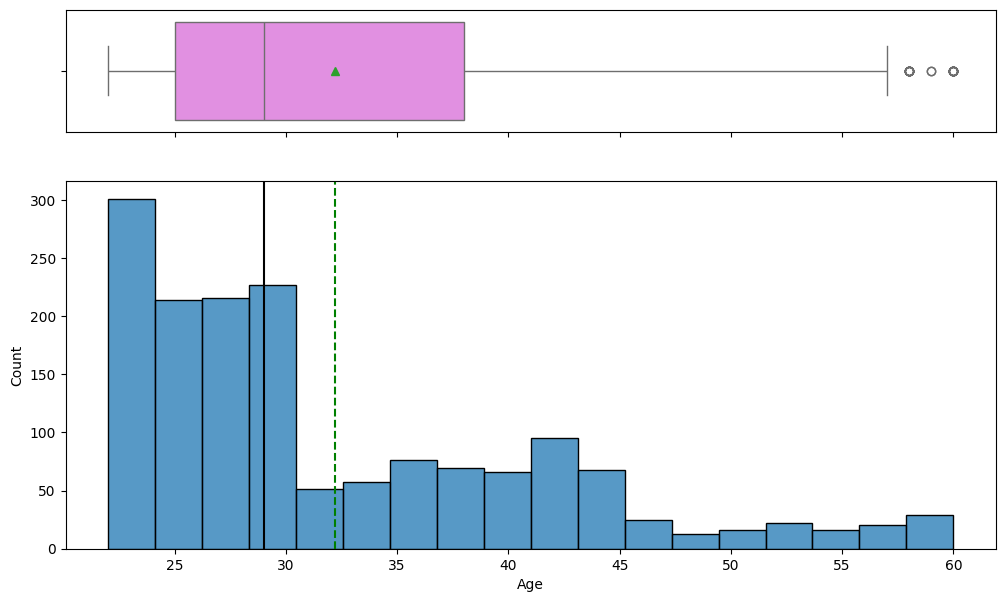

In [ ]:
## Histogram boxplot for the Age
histogram_boxplot(data,'Age')

#### Observations:

Boxplot Observations

* The median age is around 29–30 years.

* There are several upper outliers in the 50–60 age range, indicating a small older population compared to the rest.

* The distribution is right-skewed, with more younger individuals and a longer tail toward higher ages.

Histogram Observations

* The most common age group falls between 23 and 30, showing a strong concentration of younger individuals.

* After age 30, the count drops significantly and continues tapering as age increases.

* A visible decline in frequency occurs beyond 35, indicating fewer mid-career individuals.

* Very small representation exists in ages 50+.

* The mean age (green dashed line) is slightly above the median, reinforcing the right-skewed pattern where older ages pull up the average.

Overall Insights

* The age distribution heavily favors younger employees, with the majority under 30.

* The dataset shows a right-skewed distribution, driven by a small number of older-age outliers.

* Workforce appears to be predominantly early-career, with fewer mid- and late-career members.

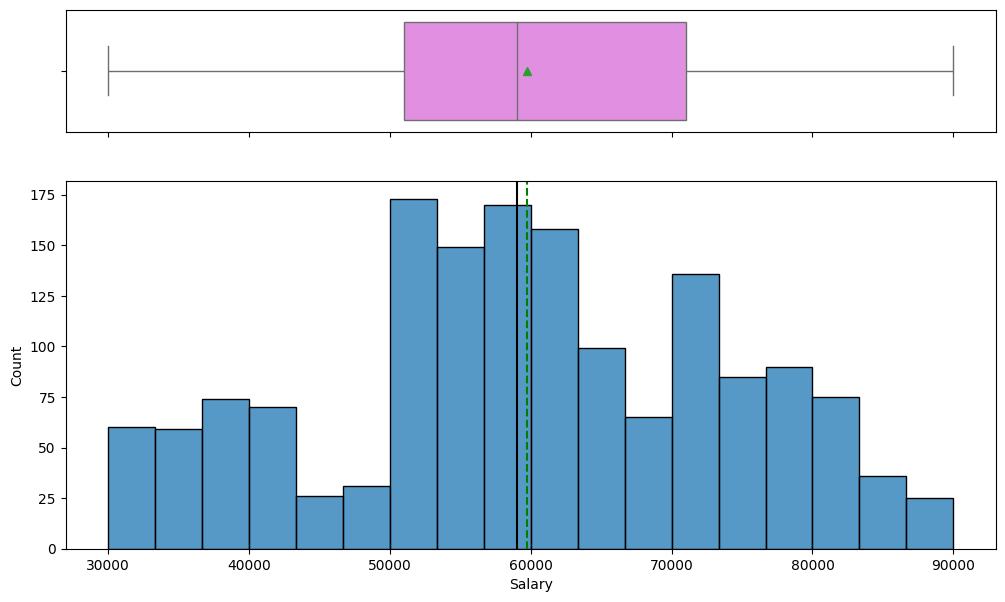

In [ ]:
## Histogram boxplot for the Salary
histogram_boxplot(data,'Salary')

#### Observations

Here are clear and concise observations from the **salary boxplot and histogram**:

### **Boxplot Observations**

* The median salary is around $60,000

* Salaries are fairly spread out, ranging roughly from 30,000 to 90,000.
* There are no significant outliers, indicating most salaries fall within a reasonable expected range.
* The mean (green point) is slightly higher than the median, suggesting a mild right skew, influenced by some higher salaries.

### **Histogram Observations**

* The distribution shows multiple peaks, suggesting **salary clustering** in specific bands.
* A large concentration of employees earns between 50,000 and 70,000.
* Smaller clusters appear in the 30,000–45,000 and 75,000–90,000 ranges.
* Very few employees earn below 35,000 or above 90,000.
* The mean salary (dashed line) sits slightly right of center, consistent with a slight right-skew.

### **Overall Insights**

* Salary distribution is broad but controlled, without extreme outliers.
* Majority of employees fall in the mid-salary segment (50k–70k).
* A modest number earn significantly higher salaries, contributing to slight skewness.
* The pattern suggests a mix of entry-level, mid-level, and a smaller group of senior/high-paid roles.


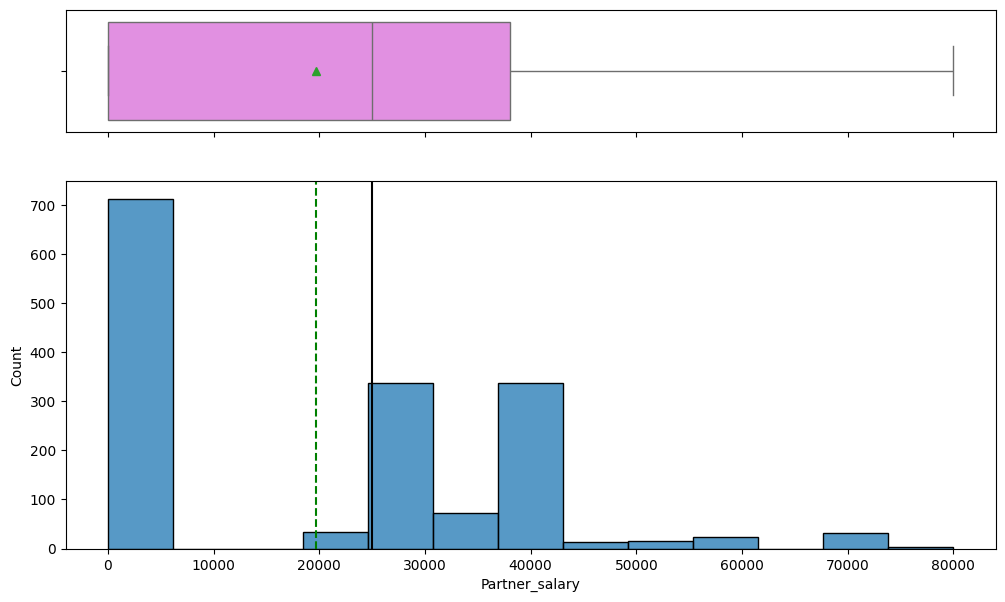

In [ ]:
## Histogram boxplot for the PartnerSalary
histogram_boxplot(data,'Partner_salary')

#### Observations

Here are clear observations from the **Partner Salary** boxplot and histogram:

### **Boxplot Observations**

* The distribution is highly right-skewed, with many very low values and a few very high salaries.
* A large portion of data sits near the bottom of the range, indicating many partners earn close to zero or low income.
* The median is around 25,000, but the mean (green triangle) is higher, pulled up by high-earning outliers.
* The upper whisker extends close to 80,000, showing the presence of significant outliers or high earners.
* The spread is wide, suggesting large variability in partner income.

### **Histogram Observations**

* A very large concentration (700+) of entries fall between \$0 and \$5,000, indicating either:

  * many partners have very low income,
  * some may not be working, or
  * non-disclosed/missing income represented as zero.
* A secondary cluster is seen around 25,000–40,000, showing a group of mid-level earners.
* Smaller peaks appear around 50,000–80,000, representing higher-earning partners but in much smaller numbers.
* Overall, the distribution is extremely uneven, dominated by low values.

### **Overall Insights**

* Partner salary distribution is heavily skewed toward low or zero income, with only a minority of partners contributing significant earnings.
* The average partner salary is misleading due to high-income outliers, while the median provides a more realistic picture.
* This pattern suggests high dependency on the primary employee’s income for many households.
* The dataset likely includes many partners who are students, unemployed, part-time workers, or whose income was not reported.

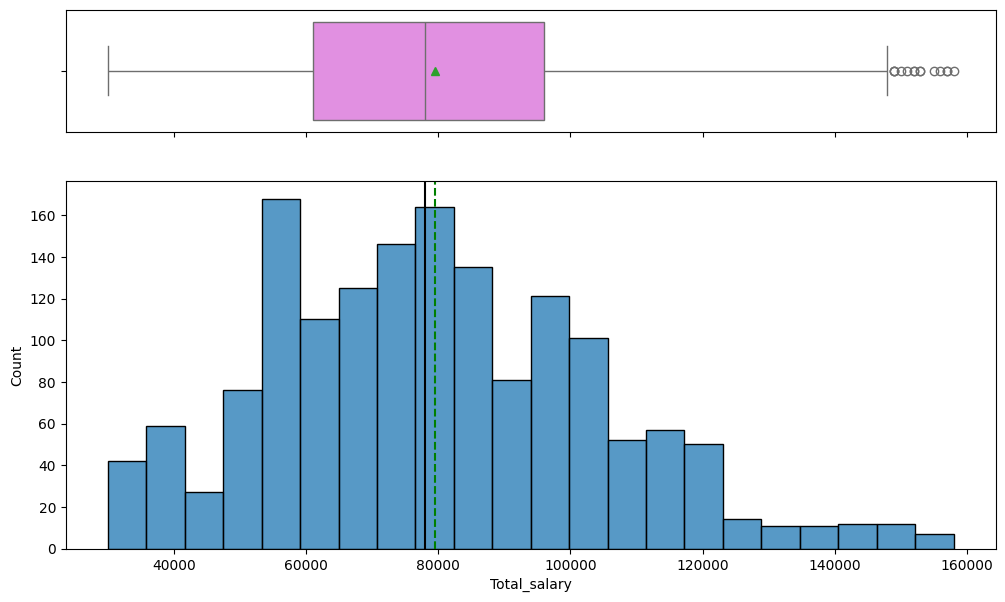

In [ ]:
## Histogram boxplot for the Total Salary
histogram_boxplot(data,'Total_salary')

#### Observations

* The partner salary distribution is extremely right-skewed, with most values concentrated between \$0 and \$5,000.
* A smaller cluster appears in the \$25,000–\$40,000 range, with only a few high earners reaching up to \$80,000.
* The mean is higher than the median due to the influence of high-income outliers.
* Overall, partner salaries show wide variation, but most households appear to depend primarily on the employee’s income.





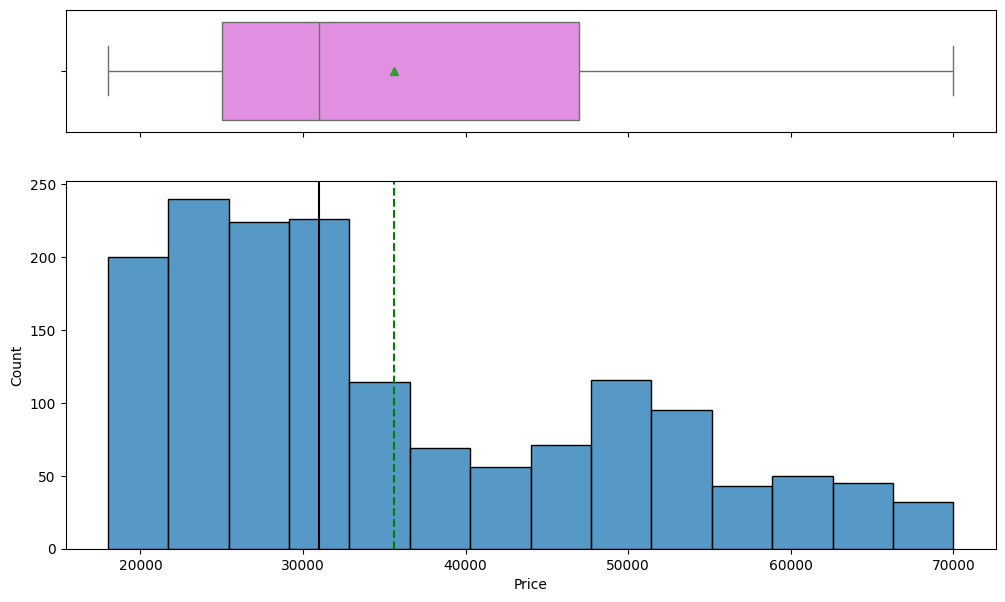

In [ ]:
## Histogram boxplot for the Price
histogram_boxplot(data,'Price')

#### Observations

* **Distribution Shape:** The distribution is visibly **left-skewed** (negatively skewed), the bulk of the data (the peak) is concentrated towards the higher price end (around the \$30,000 to \$35,000 range).
* **Central Tendency Comparison:** The **mean** (represented by the green dashed line on the histogram and the green triangle on the box plot) is located at approximately **\$35,000**, which is clearly lower than the **median** (the solid black line inside the box plot), located around **\$32,000**. This pattern (Mean < Median) is characteristic of a left-skewed distribution.
* **Interquartile Range (IQR):** The middle 50% of the prices (the pink box) is relatively compact, spanning roughly from the 25th percentile (Q1) at about **\$28,000** to the 75th percentile (Q3) at about **\$48,000**.
* **Outlier Absence and Range:** The box plot shows no visible outliers and the whiskers extend close to the minimum value (around **\$18,000**) and the maximum value (around **\$70,000**), indicating a fairly continuous spread of data within this range.

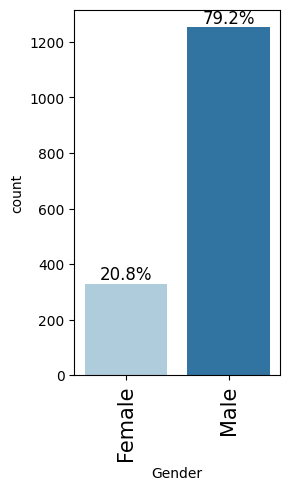

In [ ]:
labeled_barplot(data,'Gender',perc=True)

#### Observations:

* **Uneven Distribution:** The dataset exhibits a highly uneven distribution of the 'Gender' variable.
* **Majority is Male:** The **Male** category constitutes the significant majority, representing **79.2%** of the total count.
* **Minority is Female:** The **Female** category is the distinct minority, making up only **20.8%** of the total count.

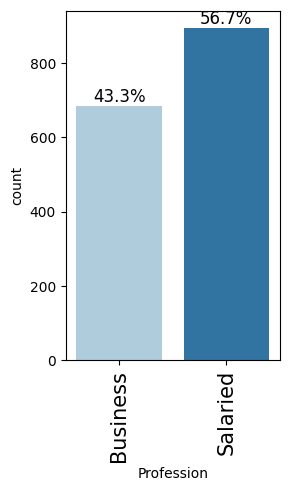

In [ ]:
labeled_barplot(data,'Profession',perc=True)

#### Observations:

* **Profession Distribution:** The chart compares the count of individuals identified as 'Business' against those identified as 'Salaried'.
* **Salaried Majority:** The 'Salaried' profession group is the **majority**, accounting for **56.7%** of the total count.
* **Business Minority:** The 'Business' profession group is the **minority**, accounting for **43.3%** of the total count.

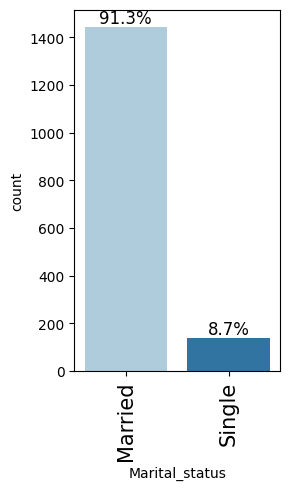

In [ ]:
labeled_barplot(data,'Marital_status',perc=True)

#### Observations:

* **Dominant Category:** The vast majority of the individuals in the dataset are **Married**.
* **Married Count/Percentage:**
    * The count of Married individuals is approximately **1420** (reading from the y-axis).
    * This group constitutes **91.3%** of the total population represented.
* **Minority Category:** A small portion of the individuals are **Single**.
* **Single Count/Percentage:**
    * The count of Single individuals is approximately **135** (reading from the y-axis).
    * This group constitutes only **8.7%** of the total population represented.
* **Skewness:** The data is highly skewed, showing a significant imbalance towards the **Married** status.

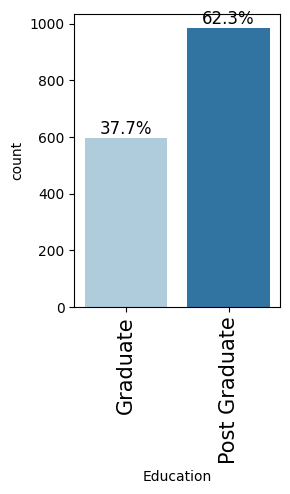

In [ ]:
labeled_barplot(data,'Education',perc=True)

#### Observations:

* **Dominant Category:** The **Post Graduate** category has a significantly **higher count** (close to 1,000) than the Graduate category (close to 600).
* **Proportion of Post Graduates:** A majority of the individuals in the dataset are Post Graduates, accounting for **$62.3\%$** of the total.
* **Proportion of Graduates:** The Graduate category accounts for the remaining **$37.7\%$** of the total.

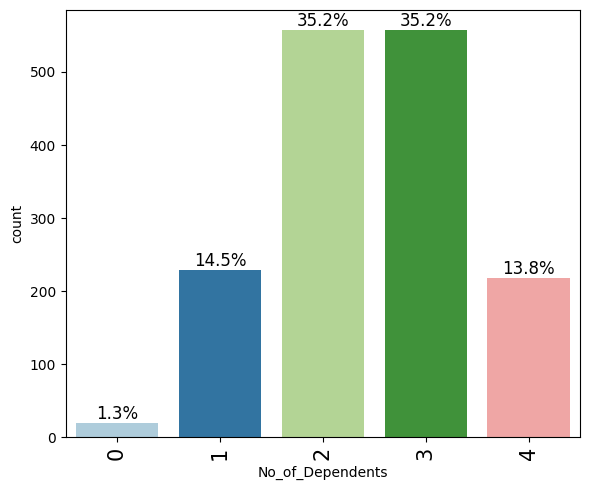

In [ ]:
labeled_barplot(data,'No_of_Dependents',perc=True)

#### Observations:

* **Most Common:** The most frequent number of dependents is **2 and 3**, with both categories accounting for the largest share of the dataset at **35.2%** each. This indicates that over two-thirds of the individuals/families in this dataset have either 2 or 3 dependents.
* **Minority with No Dependents:** A very small percentage of the population, only **1.3%**, has **0 dependents**.
* **Dependents of 1 and 4:** The categories of 1 and 4 dependents are relatively similar in proportion, though significantly less common than 2 or 3.
    * **1 dependent** makes up **14.5%**.
    * **4 dependents** makes up **13.8%**.
* **Visual Skew:** The distribution is heavily skewed towards the center categories (2 and 3), with a steep drop-off at the extreme ends (0 and 4).

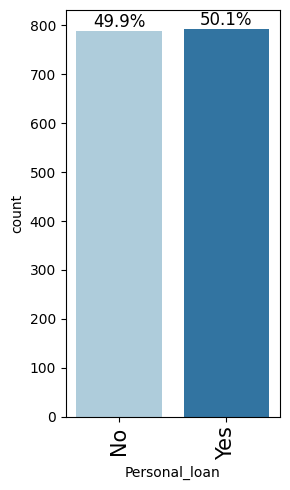

In [ ]:
labeled_barplot(data,'Personal_loan',perc=True)

#### Observations:

* Binary Variable: The Personal_loan variable is categorical and binary, meaning it only has two possible outcomes: 'No' and 'Yes'.

* Near-Perfect Balance: The distribution of the two classes ('No' and 'Yes') is remarkably balanced.

    * The 'No' category accounts for 49.9% of the observations (the lighter bar).

    * The 'Yes' category accounts for 50.1% of the observations (the darker bar).

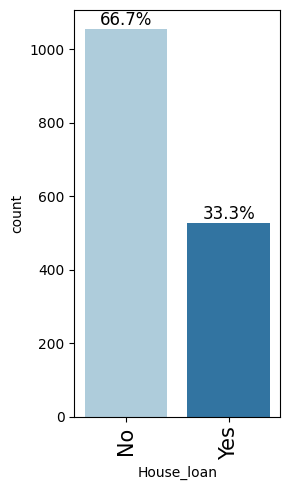

In [ ]:
labeled_barplot(data,'House_loan',perc=True)

#### Observations:


* **Total Count:** The chart displays the counts for two categories of the `House_loan` variable: **'No'** and **'Yes'**.
* **Dominant Category:** The majority of the observations fall into the **'No'** category, indicating that more people in this dataset **do not** have a house loan.
* **Counts:**
    * The count for **'No'** is approximately **1050**.
    * The count for **'Yes'** is approximately **525**.
* **Percentages (Proportions):**
    * **66.7%** of the individuals in the dataset **do not** have a house loan.
    * **33.3%** of the individuals in the dataset **do** have a house loan.
* **Ratio:** The count of 'No' responses is roughly **twice** the count of 'Yes' responses (since $66.7\% \approx 2 \times 33.3\%$). This indicates a significant imbalance in the distribution of the house loan status.

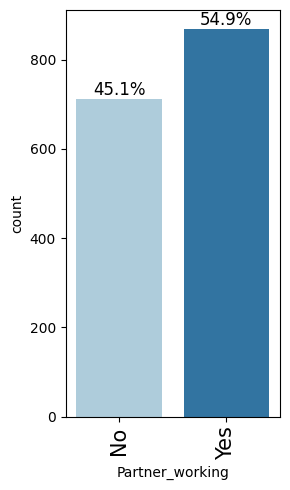

In [ ]:
labeled_barplot(data,'Partner_working',perc=True)

#### Observations:

* **Unequal Distribution:** The distribution of the `Partner_working` variable is not equal, with more individuals having a partner who is working (`Yes`) compared to those whose partner is not working (`No`).

* **Majority Partner Working:** The majority of the observations (54.9%) fall into the **"Yes"** category, indicating that more than half of the individuals in the dataset have a working partner.

* **Minority Partner Not Working:** The **"No"** category accounts for a significant but smaller portion of the observations, at **45.1%**.

* **Count Difference:** The count for those with a working partner (`Yes`) is higher (approximately 870) than the count for those whose partner is not working (`No`) (approximately 710).

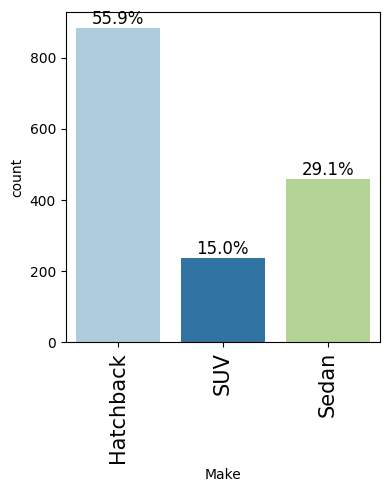

In [ ]:
labeled_barplot(data,'Make',perc=True)

#### Observations:

* **Hatchback Dominance:** The **Hatchback** category is the most frequent vehicle type, accounting for the largest percentage of the count.
    * It represents **55.9%** of the total count, which is more than half of all entries.
    * The count for Hatchbacks is approximately **880**.

* **Sedan as Second Most Frequent:** **Sedan** is the second most common vehicle type in the dataset.
    * It accounts for **29.1%** of the total count.
    * The count for Sedans is approximately **460**.

* **SUV is Least Frequent:** The **SUV** category is the least represented vehicle type.
    * It makes up only **15.0%** of the total count.
    * The count for SUVs is approximately **240**.

#### Question 7: How many cars are of make Hatchback and priced above 25000. State your observations? [2 marks]

In [ ]:
# Get the cars whose make is hatchback.
data_hatchback = data[data['Make'] == 'Hatchback']

# Get the cars which are priced above 25000.
Count_hatchback = data_hatchback[data['Price']>25000].shape[0]

print(f"The number of Hatchbacks priced above $25,000 is: {Count_hatchback}")



The number of Hatchbacks priced above $25,000 is: 444


#### Observations:

* The number of Hatchbacks priced above $25,000 is: 444


#### Question 8: How many owners have bought cars that were priced higher than their salary. How many of them have taken personal loan? [3 marks]

In [ ]:

# Find the owners whose car Price is higher than their Salary
bought_above_salary = data['Price'] > data['Salary']

# Filter the DataFrame using the first condition
data_above_salary = data[bought_above_salary]

# Calculate the total count for the first question
total_above_salary = len(data_above_salary)

# From the filtered group, check how many have a Personal_loan
taken_loan = data_above_salary['Personal_loan'] == 'Yes'

# Filter the already filtered DataFrame using the second condition
data_above_salary_and_loan = data_above_salary[taken_loan]

# Calculate the count for the second question
total_above_salary_and_loan = len(data_above_salary_and_loan)


# --- 3. Output the Results ---
print("--- Analysis Results ---")
print(f"Total number of owners who bought cars priced higher than their salary: {total_above_salary}")
print(f"Number of those owners who have taken a personal loan: {total_above_salary_and_loan}")


--- Analysis Results ---
Total number of owners who bought cars priced higher than their salary: 96
Number of those owners who have taken a personal loan: 44


#### Observations:

* Out of all $1581$ owners in the dataset, 96 (approximately $6.07\%$) purchased a vehicle where the Price of the car exceeded their Salary.

* Of those 96 owners who overextended their budget, 44 of them (approximately $45.83\%$) also reported having a personal loan.

* This suggests that a significant portion of individuals buying cars above their salary may be relying on personal loans.


### Multivariate Analysis

#### Question 9: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [15 marks]

In [ ]:
# Look at the data again

data.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int64 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int64(6), object(8)
memory usage: 173.1+ KB


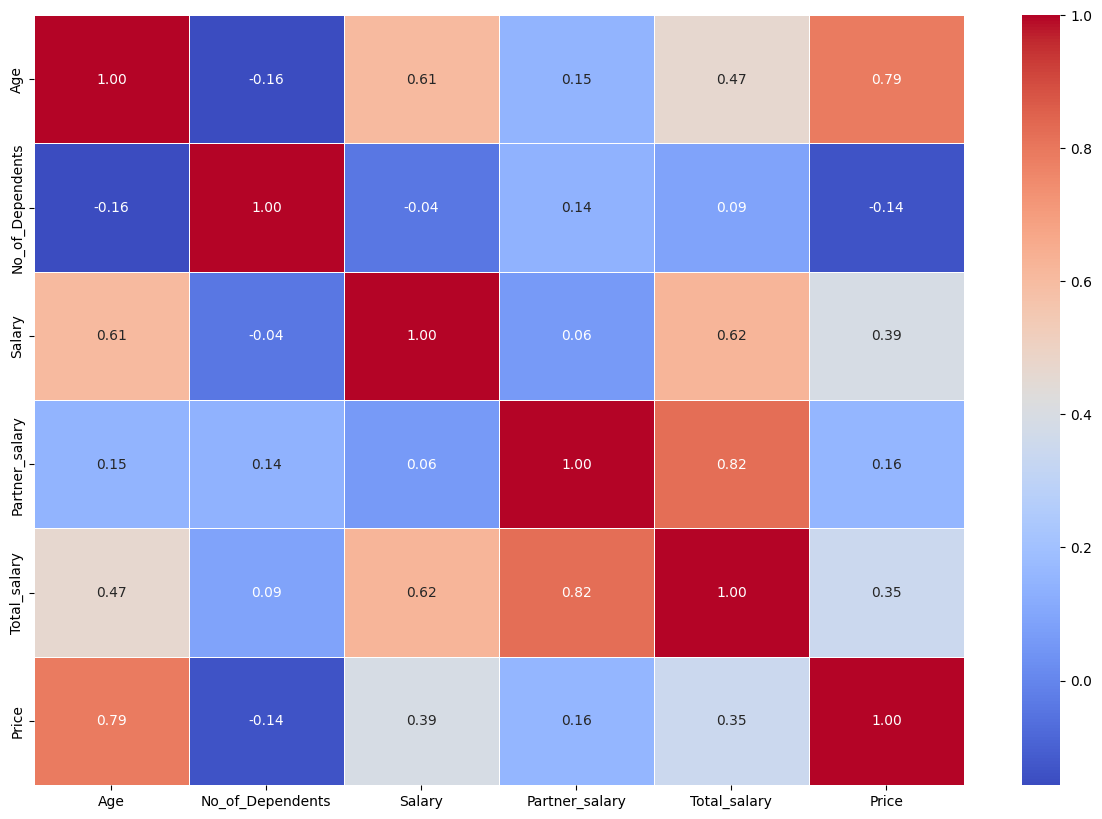

In [ ]:
# Set a color palette for the heatmap
sns.set_palette(sns.color_palette("Set2", 8))

# Set figure size for better readability
plt.figure(figsize=(15, 10))

# Plot the correlation matrix as a heatmap
# annot=True displays correlation values on the heatmap
# numeric_only = True for Numeric columns only
sns.heatmap(data.corr(numeric_only = True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Display the heatmap
plt.show()

#### Observations

* Age shows a strong positive correlation with Price (0.79), suggesting older buyers tend to purchase higher-priced items.

* Age also has a moderate positive correlation with Salary (0.61) and Total_salary (0.47).

* No. of Dependents has very weak or negative correlations with nearly all variables — it doesn't strongly influence salaries or price.

* Salary has a strong positive correlation with Total_salary (0.62), as expected.

* Partner_salary has a very strong correlation with Total_salary (0.82), meaning partner earnings heavily drive combined salary.

* Salary has a moderate correlation with Price (0.39), indicating higher earners tend to spend more, but not as strongly as Age.

* Partner_salary has weak correlation with Price (0.16).

* Total_salary has a moderate positive correlation with Price (0.35).

* No variables show extremely negative correlations—most relationships are positive or weak.

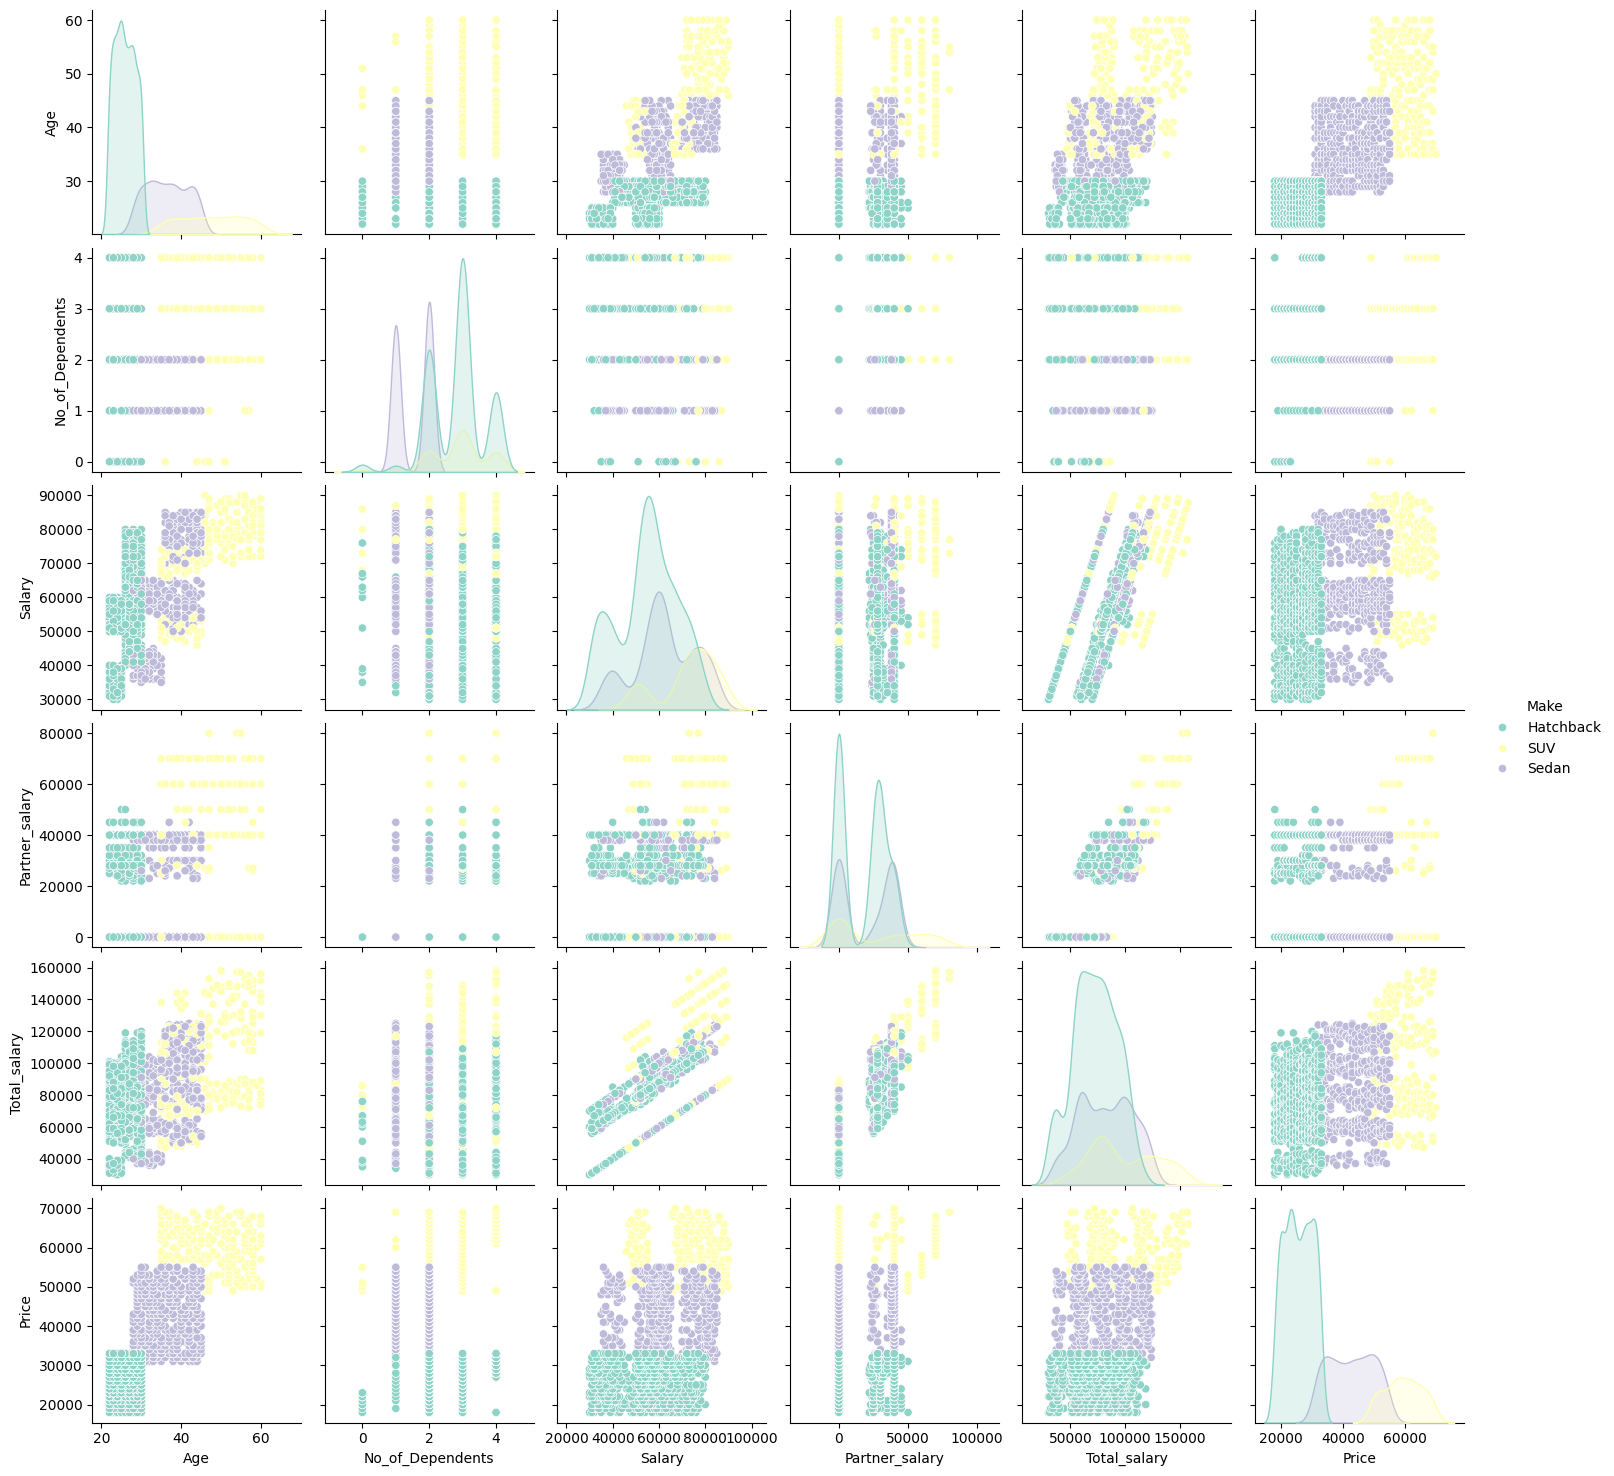

In [ ]:
# Set a color palette for the pairplot
sns.set_palette(sns.color_palette("Set3", 8))

# Create pairwise scatter plots for selected numeric variables
# hue="Make" colors points based on target variable
sns.pairplot(
    data,
    vars=['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary','Price'],
    hue="Make",
    diag_kind="kde",   # Using KDE plots on the diagonal for density visualization
    height=2.5      # Size of each subplot
)

# Display the plot
plt.show()

#### Observations

Here are clear, concise observations from the pairplot:

### **Overall Patterns**

* **SUV buyers generally have the highest Price values**, followed by **Sedans**, and **Hatchbacks** tend to be the lowest-priced.
* **SUV buyers also tend to have higher Salary, Partner_salary, and Total_salary** when compared to Hatchback and Sedan buyers.
* **Hatchback buyers cluster at lower salaries and lower price ranges**, indicating more budget-conscious purchases.

### **Age Patterns**

* **SUV buyers appear older on average**, while Hatchback buyers skew younger.
* Older individuals tend to choose **higher-priced vehicles**, visible in Age vs Price.

### **Salary Relationships**

* **Salary vs Price** shows a positive trend: higher salaried individuals typically buy more expensive cars.
* **SUV buyers dominate the upper salary ranges**, while Hatchback buyers dominate the lower ranges.

### **Partner Salary & Total Salary**

* Higher **Partner_salary** and **Total_salary** are more frequently associated with **SUV purchases**.
* Hatchback buyers are more concentrated in lower total-income brackets.

### **No. of Dependents**

* The number of dependents does **not show a strong visual relationship** with Price or Make.
* All car types are spread similarly across 0–5 dependents, indicating dependents don't strongly influence car choice.

### **Distribution Observations**

* **Salary, Partner_salary, and Total_salary distributions differ by Make**:

  * SUV distributions shift right (higher incomes).
  * Hatchback distributions shift left (lower incomes).
  * Sedan distributions sit in between.
* **Price distribution** clearly separates by Make:

  * SUV → high price cluster
  * Sedan → mid-range
  * Hatchback → low price cluster

### **Correlation-like Visual Patterns**

* **Total_salary shows the strongest upward pattern with Price**, consistent across all makes.
* **Age and Price** also show visible positive association.


#### Make vs Age

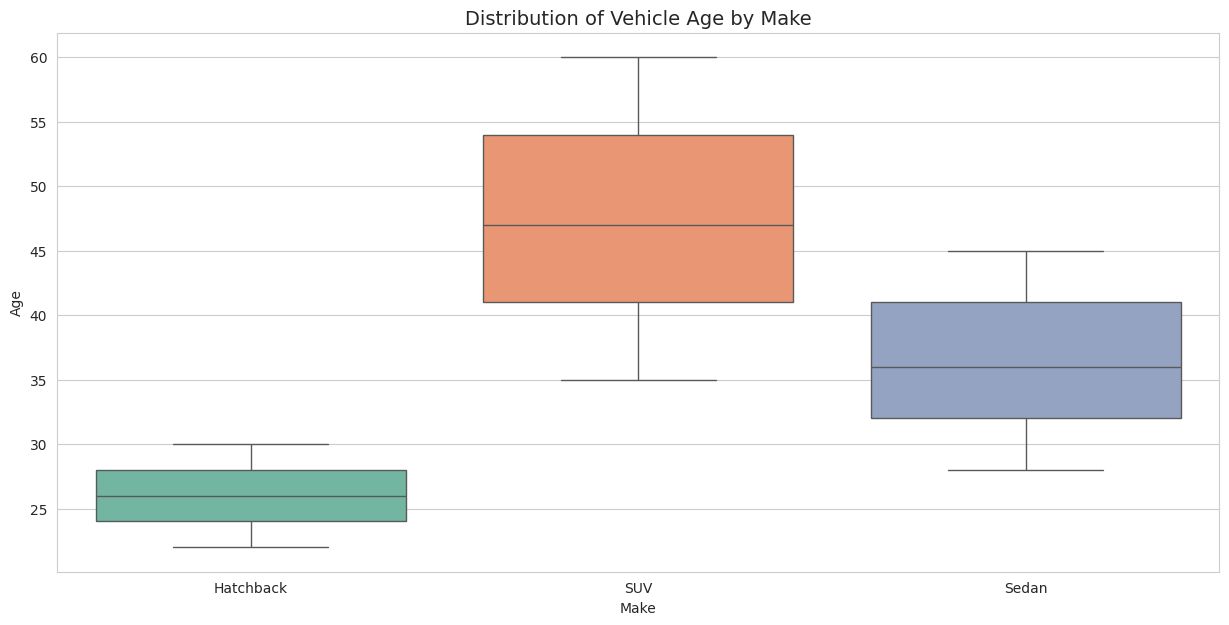

In [ ]:
# Set plot style
sns.set_style("whitegrid")

# Create the boxplot
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=data,
    x="Make",
    y="Age",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Age by Make", fontsize=14)
plt.xlabel("Make")
plt.ylabel("Age")

# Display the plot
plt.show()

#### Observations

* SUVs have the highest vehicle age overall, with a median around the mid-to-high 40s and the widest age spread.

* Hatchbacks are the youngest vehicles, with a median age in the mid-20s and a relatively tight distribution.

* Sedans fall in between, with a median age in the mid-30s.

* Age variability is greatest for SUVs, indicating a mix of both newer and much older vehicles.

* Hatchbacks show the least variability, suggesting more consistency in their ages.

* The maximum age is highest for SUVs (reaching around 60), while hatchbacks cap out much lower (around 30).

* There is minimal overlap between hatchbacks and SUVs, highlighting a clear difference in age profiles across these makes.

* Sedans overlap with both hatchbacks and SUVs, indicating a transitional age distribution.

#### Make vs Price

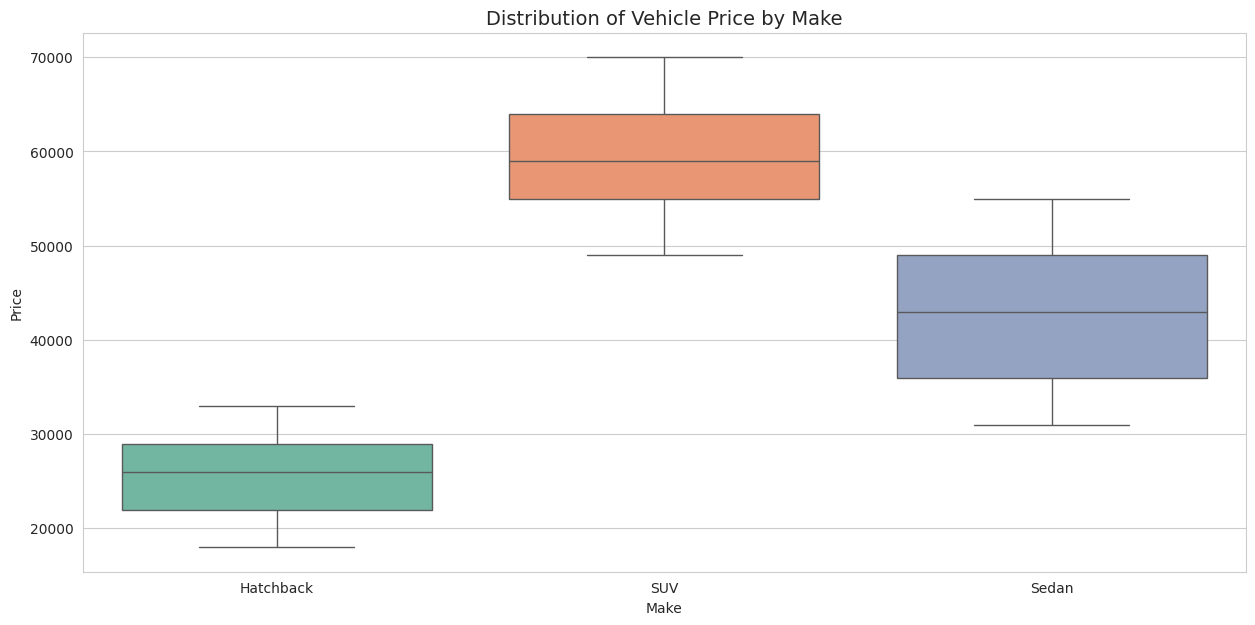

In [ ]:
# Set plot style
sns.set_style("whitegrid")

# Create the boxplot
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=data,
    x="Make",
    y="Price",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Price by Make", fontsize=14)
plt.xlabel("Make")
plt.ylabel("Price")

# Display the plot
plt.show()

#### Observations

* SUVs are the most expensive vehicles, with the highest median price (around the high-50Ks) and the highest overall price range.

* Hatchbacks are the most affordable segment, with a median price in the mid-20Ks and a relatively narrow price spread.

* Sedans are priced between hatchbacks and SUVs, with a median in the low-40Ks.

* Price variability is greatest for SUVs, indicating a wide mix of mid-range and premium models.

* Hatchbacks show the least price variation, suggesting more consistent pricing within this segment.

* Sedans exhibit moderate variability, overlapping with higher-end hatchbacks and lower-end SUVs.

* There is minimal overlap between hatchback and SUV prices, highlighting clear market segmentation.

* Upper-end sedans approach lower-end SUV prices, indicating potential cross-shopping behavior.

##### Make vs Salary

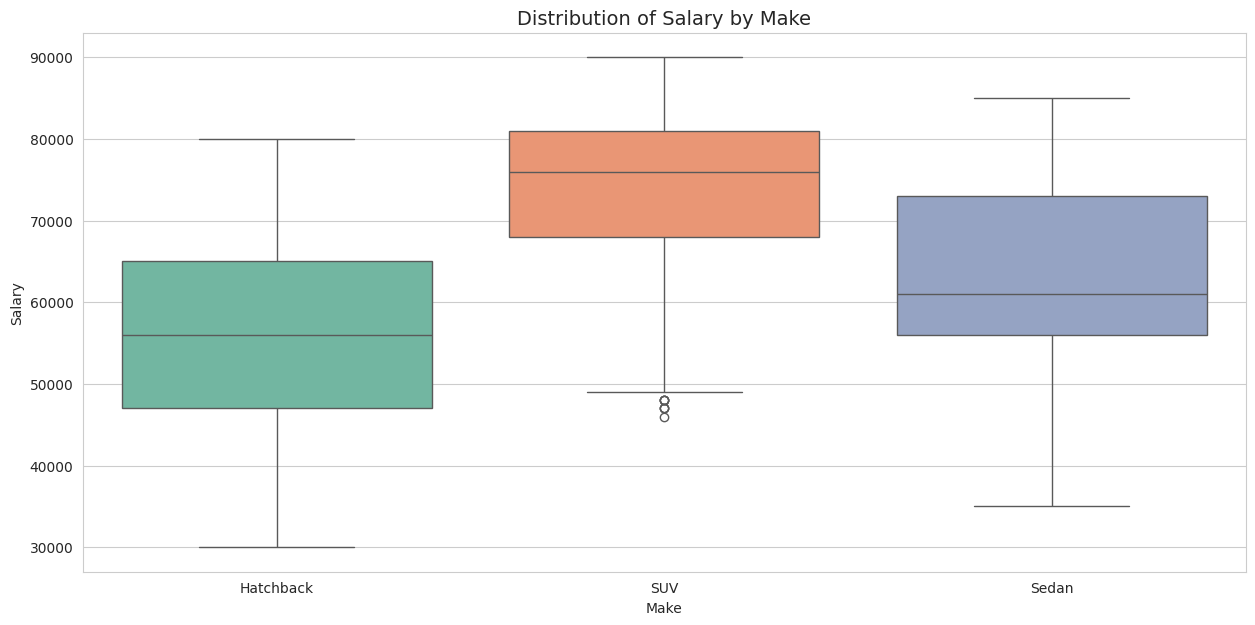

In [ ]:
# Set plot style
sns.set_style("whitegrid")

# Create the boxplot
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=data,
    x="Make",
    y="Salary",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Salary by Make", fontsize=14)
plt.xlabel("Make")
plt.ylabel("Salary")

# Display the plot
plt.show()

#### Observations

* SUV buyers have the highest median salary, centered in the mid-to-high 70Ks.

* Hatchback buyers have the lowest median salary, around the mid-50Ks.

* Sedan buyers fall in between, with a median salary in the low-60Ks.

* Salary variability is highest for sedan buyers, indicating a wide income mix within this segment.

* SUV salaries show a relatively tight interquartile range, suggesting more consistent buyer income levels.

* Hatchbacks include the lowest salary range overall, extending down to around 30K.

* Low-salary outliers appear in the SUV segment, indicating a small number of lower-income buyers opting for SUVs.

* There is notable overlap between hatchback and sedan salaries, while SUV buyers are generally distinct at higher income levels.

##### Make vs Education

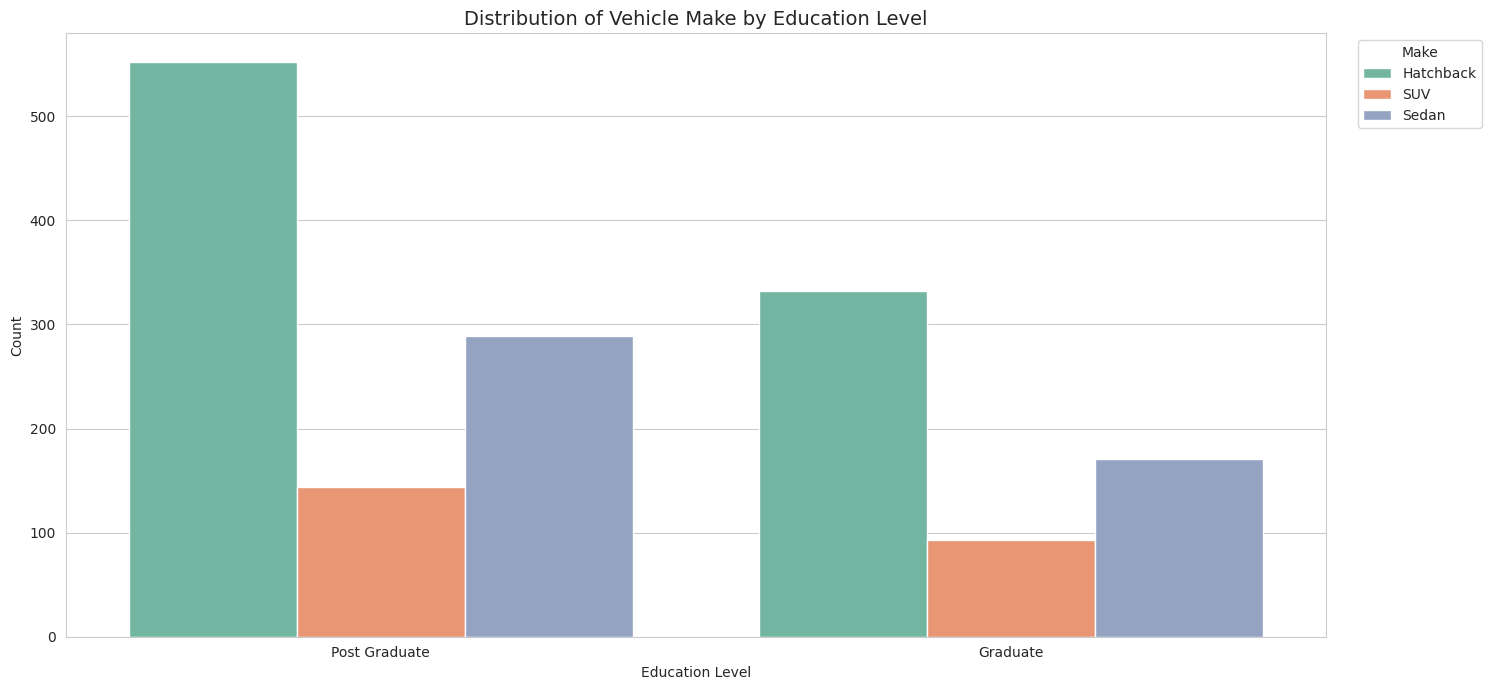

In [ ]:
# Set visual style
sns.set_style("whitegrid")

# Create count plot
plt.figure(figsize=(15, 7))
sns.countplot(
    data=data,
    x="Education",
    hue="Make",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Make by Education Level", fontsize=14)
plt.xlabel("Education Level")
plt.ylabel("Count")

# Improve legend placement
plt.legend(title="Make", bbox_to_anchor=(1.02, 1), loc="upper left")

# Display plot
plt.tight_layout()
plt.show()


#### Observation

Here are key observations from the "Distribution of Vehicle Make by Education Level" chart:

* Overall Dominance: Hatchbacks are the most frequently owned vehicle make across both Post Graduate and Graduate education levels.

* Post Graduate Preference: Among Post Graduates, Hatchbacks are overwhelmingly preferred (over 500 units), followed by Sedans (around 290 units), and then SUVs (around 140 units).

* Graduate Preference: For Graduates, Hatchbacks are also the most popular (around 330 units), followed by Sedans (around 170 units), and SUVs (around 90 units).

* Sedan vs. SUV: In both education groups, Sedans are the second most popular vehicle make, significantly outpacing SUVs.

* Volume Comparison: The total count of vehicles for the Post Graduate group appears to be higher than the total count for the Graduate group across all vehicle makes.


##### Make vs No_of_Dependents

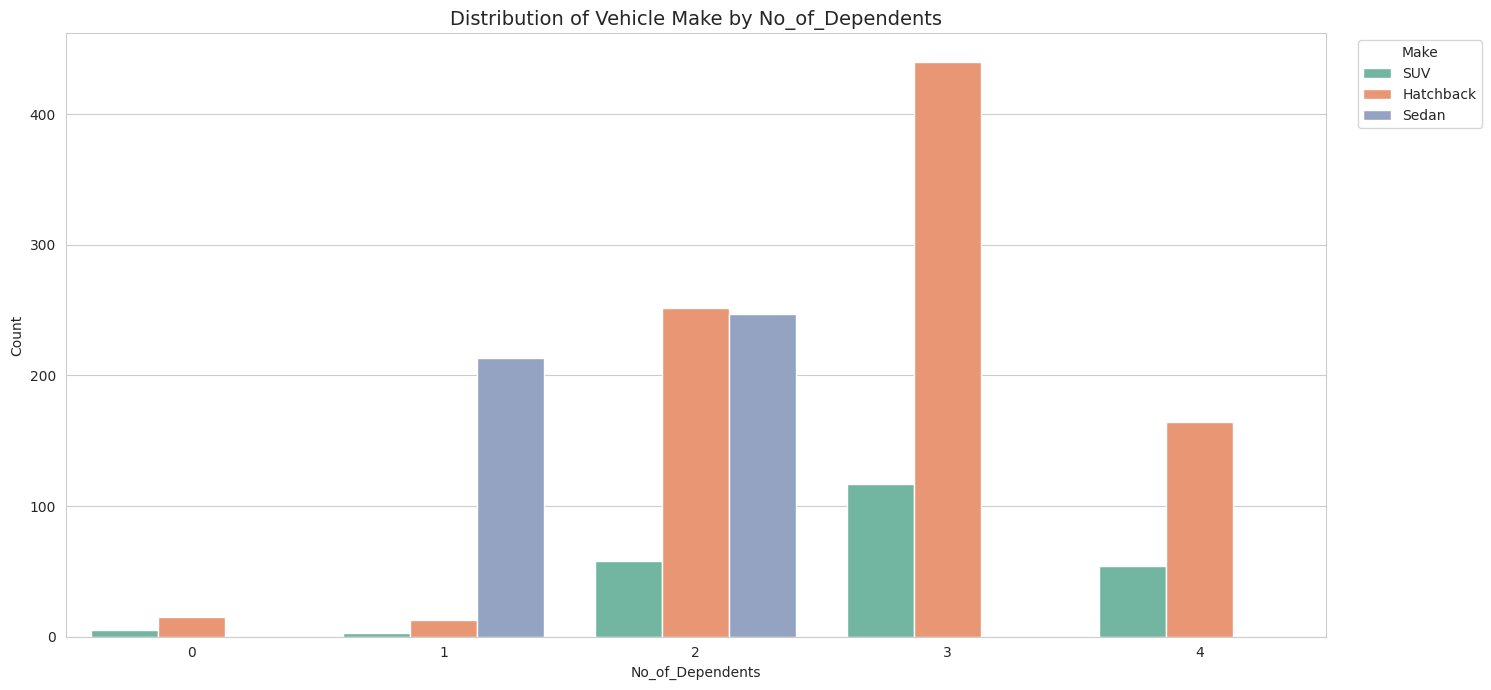

In [ ]:
# Create count plot
plt.figure(figsize=(15, 7))
sns.countplot(
    data=data,
    x="No_of_Dependents",
    hue="Make",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Make by No_of_Dependents", fontsize=14)
plt.xlabel("No_of_Dependents")
plt.ylabel("Count")

# Improve legend placement
plt.legend(title="Make", bbox_to_anchor=(1.02, 1), loc="upper left")

# Display plot
plt.tight_layout()
plt.show()

#### Observations

* Zero Dependents (0): This group has the lowest overall volume, with very few SUVs and Sedans and a minimal number of Hatchbacks (around 15).

* One Dependent (1): This group shows a very strong preference for Sedans (over 200 units), with very few Hatchbacks and almost no SUVs.

* Two Dependents (2): This group has a near-even split between Hatchbacks (around 250 units) and Sedans (around 240 units). SUVs are the least popular, but their volume increases noticeably to around 55 units.

* Three Dependents (3) - Peak Hatchback: This group has the highest overall vehicle count, with a dominant preference for Hatchbacks (over 420 units). SUVs also peak in this group at around 120 units, while Sedans (around 240 units) remain popular.

* Four Dependents (4) - Hatchback Preference: In this group, Hatchbacks are still the most popular (around 160 units). SUVs are the least common (around 50 units), followed by Sedans (around 0 units), indicating Sedans are not a popular choice for families with four dependents.

* SUV Trend: The count of SUVs generally increases as the number of dependents increases from 0 to 3, and then slightly decreases at 4 dependents, suggesting they are a preference for mid-sized families.

* Sedan Trend: Sedan preference peaks at 1 and 2 dependents, then drops significantly for 3 and is virtually non-existent for 4 dependents.

##### Make vs Profession

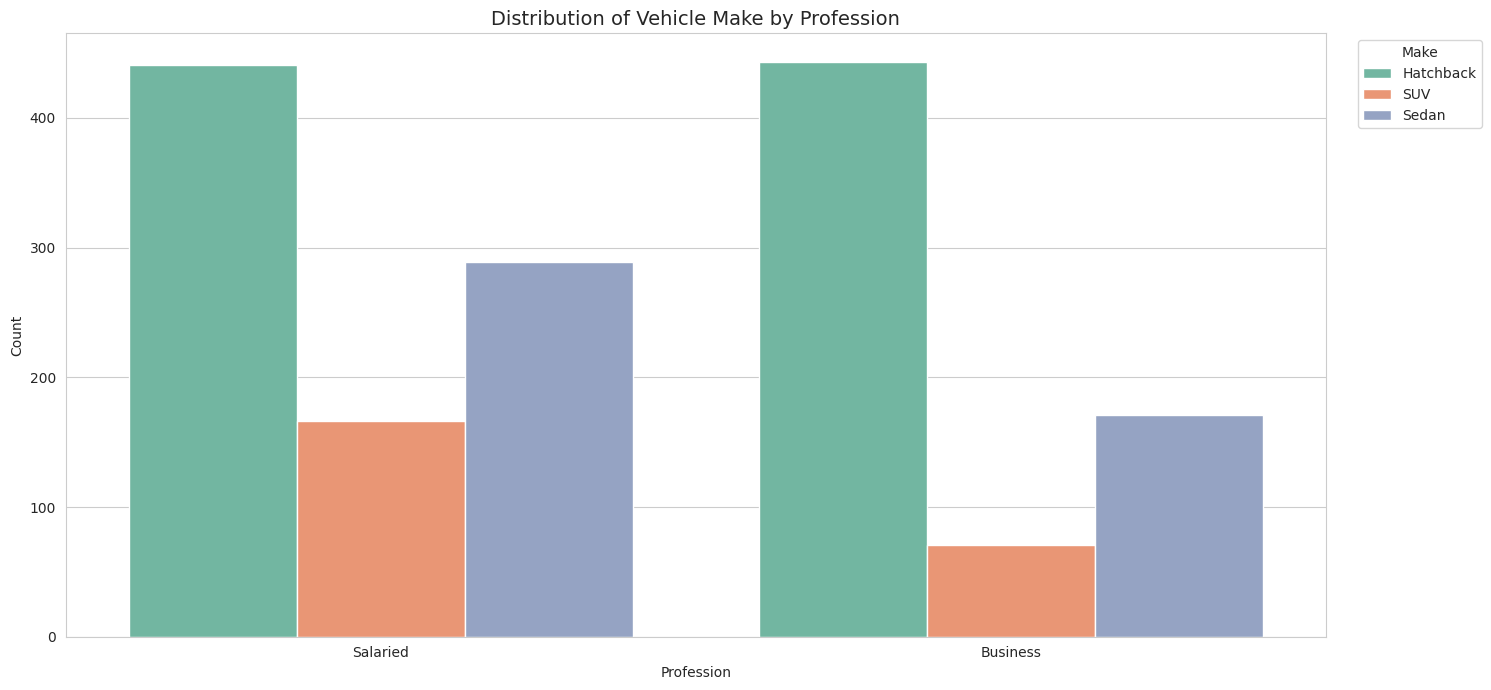

In [ ]:
# Create count plot
plt.figure(figsize=(15, 7))
sns.countplot(
    data=data,
    x="Profession",
    hue="Make",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Make by Profession", fontsize=14)
plt.xlabel("Profession")
plt.ylabel("Count")

# Improve legend placement
plt.legend(title="Make", bbox_to_anchor=(1.02, 1), loc="upper left")

# Display plot
plt.tight_layout()
plt.show()

#### Observations

* Hatchback Dominance: Hatchbacks are the most popular vehicle make for both Salaried and Business professionals, with counts slightly above 400 for both groups.

* Salaried Professionals' Preference: Salaried professionals show the highest count for Sedans (around 290 units) and the second highest count for SUVs (around 165 units) within this group.

* Business Professionals' Preference: Business professionals show a similar strong preference for Hatchbacks (slightly over 400 units), but their second preference is Sedans (around 170 units).

* SUV Contrast: Salaried professionals purchase significantly more SUVs (around 165 units) than Business professionals (around 70 units).

* Sedan Contrast: Salaried professionals purchase significantly more Sedans (around 290 units) than Business professionals (around 170 units).

* Total Volume: The total number of vehicles is higher for the Salaried professional group compared to the Business professional group across all vehicle makes.

##### Make vs Personal loan

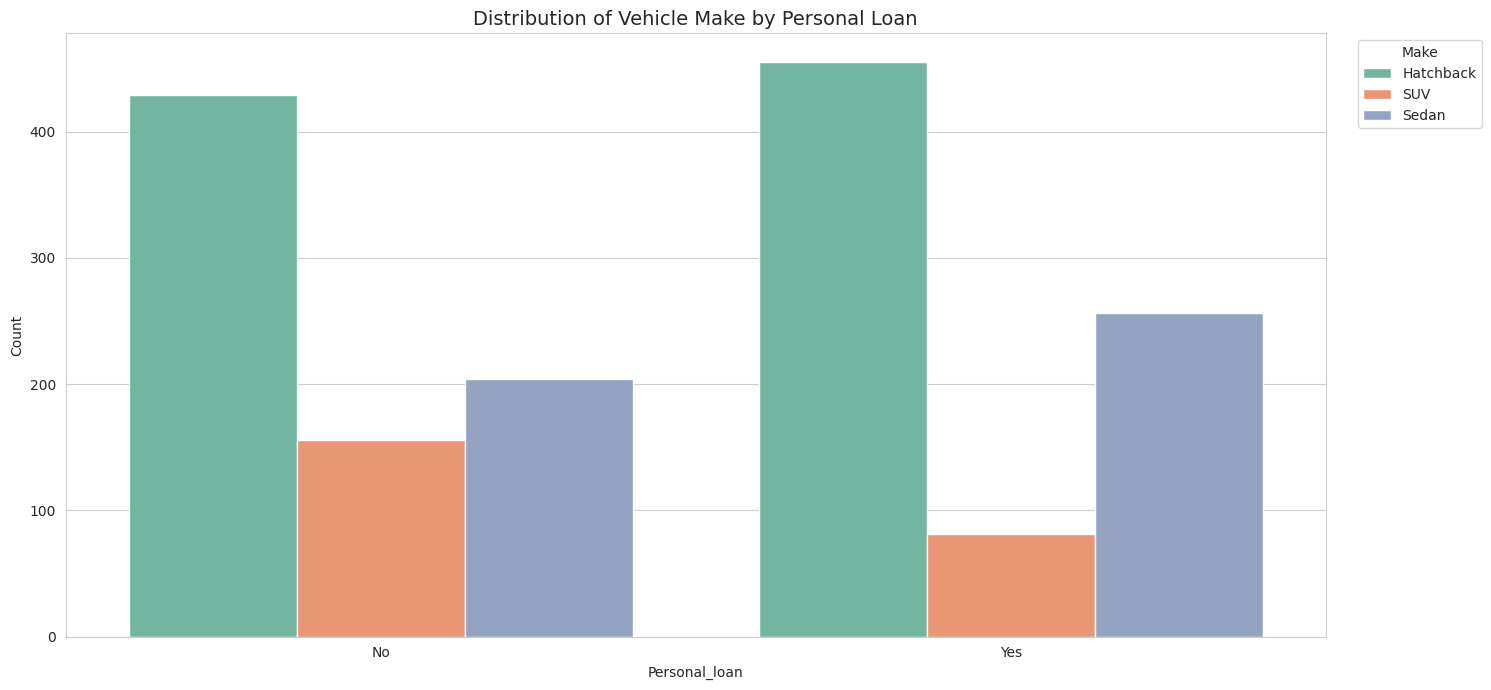

In [ ]:
# Create count plot
plt.figure(figsize=(15, 7))
sns.countplot(
    data=data,
    x="Personal_loan",
    hue="Make",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Make by Personal Loan", fontsize=14)
plt.xlabel("Personal_loan")
plt.ylabel("Count")

# Improve legend placement
plt.legend(title="Make", bbox_to_anchor=(1.02, 1), loc="upper left")

# Display plot
plt.tight_layout()
plt.show()

#### Observations

* Overall Hatchback Preference: Hatchbacks are the most popular vehicle make for both customers who do not have a personal loan and those who do have one.

* Customers Without a Loan ("No"): This group's preferences are spread, with Hatchbacks (around 420 units) being the highest, followed by Sedans (around 200 units), and SUVs (around 150 units).

* Customers With a Loan ("Yes"): This group has the highest overall count, showing the strongest preference for Hatchbacks (around 450 units). Their second preference is Sedans (around 260 units).

* SUV Contrast: Customers without a personal loan (around 150 units) purchase significantly more SUVs than customers with a personal loan (around 80 units).

* Sedan Contrast: Customers with a personal loan (around 260 units) purchase more Sedans than customers without a personal loan (around 200 units).

* High Volume for "Yes" Group: The group with a personal loan ("Yes") shows a higher count for both Hatchbacks and Sedans compared to the "No" group, but a lower count for SUVs.

##### Make vs House loan

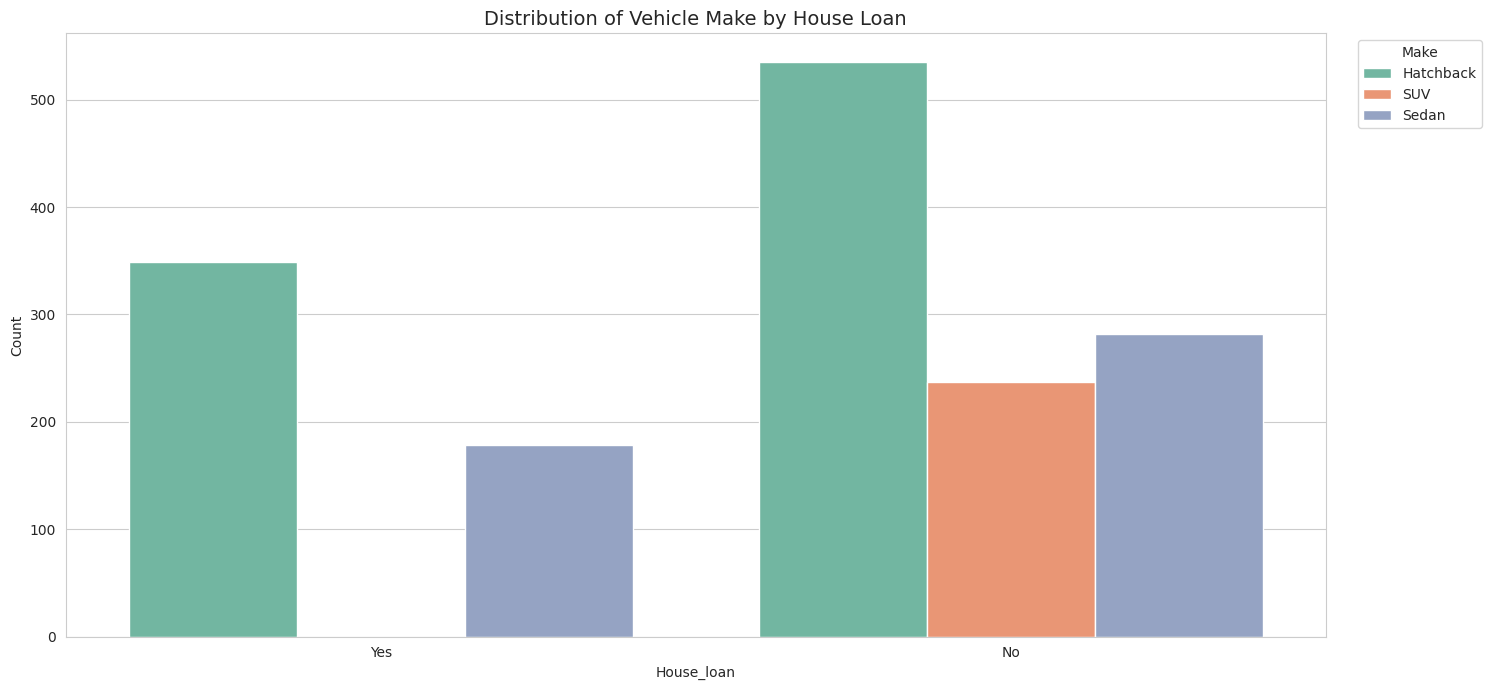

In [ ]:
# Create count plot
plt.figure(figsize=(15, 7))
sns.countplot(
    data=data,
    x="House_loan",
    hue="Make",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Make by House Loan", fontsize=14)
plt.xlabel("House_loan")
plt.ylabel("Count")

# Improve legend placement
plt.legend(title="Make", bbox_to_anchor=(1.02, 1), loc="upper left")

# Display plot
plt.tight_layout()
plt.show()

#### Observations

* Overall Hatchback Dominance: Hatchbacks are the most popular vehicle make for both customers who do have a house loan and those who do not have one.

* Customers Without a Loan ("No") - Peak Hatchback: This group has the highest overall volume and the highest count of Hatchbacks (over 520 units). They also show significant counts for Sedans (around 280 units) and SUVs (around 240 units).

* Customers With a Loan ("Yes") - Lower Volume: This group has a much lower overall volume compared to the "No" group. Their preferences are led by Hatchbacks (around 350 units), followed by Sedans (around 180 units).

* SUV Absence in "Yes" Group: Customers with a house loan ("Yes") show a near-zero count for SUVs, which is a sharp contrast to the high SUV volume in the "No" group (around 240 units).

* Sedan and Hatchback Preference in "Yes" Group: For customers with a house loan, the preference is concentrated almost entirely between Hatchbacks and Sedans.

* Volume Disparity: The volume of all vehicle makes is significantly higher for the customers who do not have a house loan ("No") compared to those who do have one ("Yes"), suggesting that non-homeowners might represent a larger segment of the vehicle buying market shown in this data.

##### Make vs Partner Working

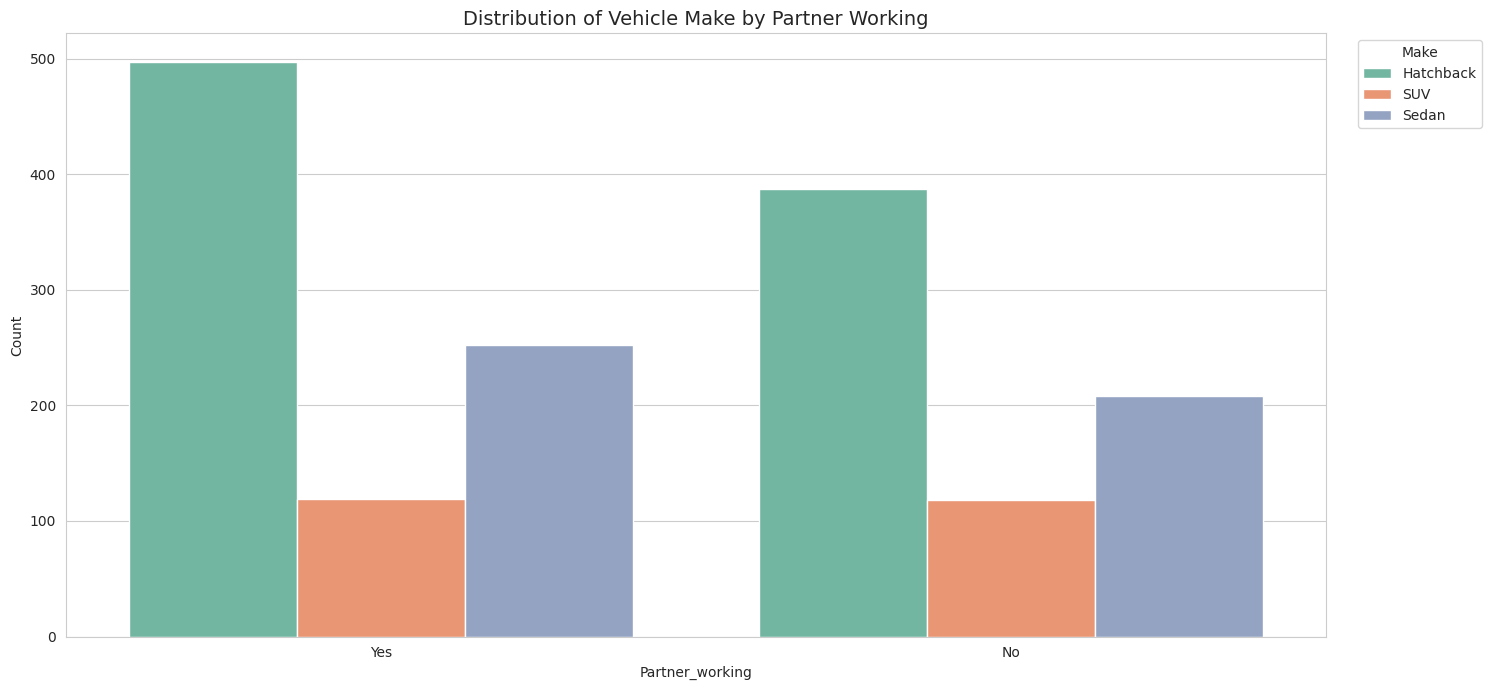

In [ ]:
# Create count plot
plt.figure(figsize=(15, 7))
sns.countplot(
    data=data,
    x="Partner_working",
    hue="Make",
    palette="Set2"
)

# Add titles and labels
plt.title("Distribution of Vehicle Make by Partner Working", fontsize=14)
plt.xlabel("Partner_working")
plt.ylabel("Count")

# Improve legend placement
plt.legend(title="Make", bbox_to_anchor=(1.02, 1), loc="upper left")

# Display plot
plt.tight_layout()
plt.show()

#### Observations

* Overall Hatchback Dominance: Hatchbacks are the most popular vehicle make regardless of whether the customer's partner is working or not.

* Partner Working ("Yes") - Highest Volume: The group where the Partner is Working ("Yes") shows the highest overall volume and the peak count for Hatchbacks (around 500 units).

* Partner Working ("Yes") - Preference Order: For this group, the preference order is clearly Hatchback (around 500), followed by Sedan (around 250), and then SUV (around 120).

* Partner Not Working ("No") - Lower Volume: The group where the Partner is Not Working ("No") has a lower overall vehicle count. Their preference order is Hatchback (around 385), followed by Sedan (around 205), and then SUV (around 120).

* SUV Consistency: The count for SUVs is remarkably similar between both groups, sitting at approximately 120 units, suggesting that a partner's working status has little influence on SUV purchase volume.

* Sedan and Hatchback Volume: Both Hatchbacks and Sedans are purchased in notably higher volumes when the partner is working ("Yes") compared to when the partner is not working ("No").

#### Grouping data for all the 3 Car segments

In [ ]:
# Filtering the dataset to include only Hatchback vehicles
# and generating descriptive statistics for all columns
# (numeric and categorical)
data[data["Make"] == "Hatchback"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,884.000000,884,884,884,884,884.000000,884,884,884,884.000000,884.000000,884.000000,884.000000,884
unique,NaN,2,2,2,2,NaN,2,2,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Business,Married,Post Graduate,NaN,Yes,No,Yes,NaN,NaN,NaN,NaN,Hatchback
freq,NaN,869,443,800,552,NaN,455,535,497,NaN,NaN,NaN,NaN,884
mean,25.874434,NaN,NaN,NaN,NaN,2.820136,NaN,NaN,NaN,54969.457014,17707.013575,72676.470588,25561.085973,NaN
std,2.520373,NaN,NaN,NaN,NaN,0.806543,NaN,NaN,NaN,12798.737168,16250.833815,20078.257725,4425.257139,NaN
min,22.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,30000.000000,0.000000,30000.000000,18000.000000,NaN
25%,24.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,47000.000000,0.000000,58000.000000,22000.000000,NaN
50%,26.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,56000.000000,25000.000000,73000.000000,26000.000000,NaN
75%,28.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,65000.000000,30000.000000,88000.000000,29000.000000,NaN


#### Observations


  * **Age Profile:** Hatchback owners are significantly younger, with an average age of approximately **$25.87$ years**. The age range is very narrow, from $22$ to $30$ years.
  * **Gender Skew:** There is an overwhelming majority of **Male ($98.3\%$)** owners for Hatchbacks.
  * **Family Size (Dependents):** The average number of dependents is approximately **$2.82$**, which is higher than the Sedan owners' mean.
  * **Marital Status:** A high percentage of owners are **Married ($90.5\%$)**.
  * **Profession:** The split between **Business ($50.11\%$)** and **Salaried ($49.89\%$)** professionals is almost perfectly even.
  * **Education:** The majority of owners hold a **Post Graduate ($62.44\%$)** degree.
  
  * **Vehicle Price:** The average price of a Hatchback is approximately **$\$25,561.10$**, which is substantially lower than the average Sedan price. The price range is from $\$18,000$ to $\$33,000$.
  * **Owner's Salary:** The owner's average individual salary is **$\$54,969.50$**.
  * **Partner's Contribution:** Slightly more than half of the owners **($56.22\%$)** have a working partner.
  * **Loan Status (Personal):** A marginal majority **($51.47\%$)** of Hatchback owners have a personal loan.
  * **Loan Status (Housing):** Most Hatchback owners **($60.52\%$)** do *not* have a house loan.

In [ ]:
# Filtering the dataset to include only Sedan vehicles
# and generating descriptive statistics for all columns
# (numeric and categorical)
data[data["Make"] == "Sedan"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,460.000000,460,460,460,460,460.000000,460,460,460,460.000000,460.000000,460.000000,460.000000,460
unique,NaN,2,2,2,2,NaN,2,2,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Salaried,Married,Post Graduate,NaN,Yes,No,Yes,NaN,NaN,NaN,NaN,Sedan
freq,NaN,259,289,422,289,NaN,256,282,252,NaN,NaN,NaN,NaN,460
mean,36.458696,NaN,NaN,NaN,NaN,1.536957,NaN,NaN,NaN,62213.043478,20028.260870,82241.304348,42671.739130,NaN
std,5.093080,NaN,NaN,NaN,NaN,0.499175,NaN,NaN,NaN,13195.787416,18584.355909,23929.007894,7096.507565,NaN
min,28.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,35000.000000,0.000000,36000.000000,31000.000000,NaN
25%,32.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,56000.000000,0.000000,61000.000000,36000.000000,NaN
50%,36.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,61000.000000,27000.000000,82000.000000,43000.000000,NaN
75%,41.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,73000.000000,38000.000000,101250.000000,49000.000000,NaN


#### Observations

  * **Age Profile:** The average age of a Sedan owner is approximately **$36.46$ years**, with ages ranging from $28$ to $45$.
  * **Marital Status:** A vast majority of Sedan owners, **$91.74\%$**, are married.
  * **Professional Status:** The highest proportion of Sedan owners are **Salaried ($62.83\%$)** professionals.
  * **Education Level:** The most common education level among Sedan owners is **Post Graduate ($62.83\%$)**.
  * **Household Income:** The average total household salary (including partner's salary) is approximately **$\$82,241.30$**, with the owner's average individual salary being around **$\$62,213.00$**.
  * **Partner Status:** Slightly more than half of the Sedan owners **($54.78\%$)** have a working partner.
  * **Loan Status (Personal):** A slight majority of Sedan owners **($55.65\%$)** have a personal loan.
  * **Loan Status (Housing):** Most Sedan owners **($61.3\%$)** do *not* have a house loan.
  * **Vehicle Price:** The average price paid for the Sedan is approximately **$\$42,671.70$**, ranging from $\$31,000$ to $\$55,000$.

In [ ]:
# Filtering the dataset to include only SUV vehicles
# and generating descriptive statistics for all columns
# (numeric and categorical)
data[data["Make"] == "SUV"].describe(include="all")

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
count,237.000000,237,237,237,237,237.000000,237,237,237,237.000000,237.000000,237.000000,237.000000,237
unique,NaN,2,2,2,2,NaN,2,1,2,NaN,NaN,NaN,NaN,1
top,NaN,Male,Salaried,Married,Post Graduate,NaN,No,No,Yes,NaN,NaN,NaN,NaN,SUV
freq,NaN,124,166,221,144,NaN,156,237,119,NaN,NaN,NaN,NaN,237
mean,47.603376,NaN,NaN,NaN,NaN,2.894515,NaN,NaN,NaN,72683.544304,26632.911392,99316.455696,59303.797468,NaN
std,7.733023,NaN,NaN,NaN,NaN,0.839600,NaN,NaN,NaN,12165.048890,28590.109059,30509.741833,5829.544340,NaN
min,35.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,46000.000000,0.000000,47000.000000,49000.000000,NaN
25%,41.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,68000.000000,0.000000,76000.000000,55000.000000,NaN
50%,47.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,76000.000000,25000.000000,89000.000000,59000.000000,NaN
75%,54.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,81000.000000,50000.000000,125000.000000,64000.000000,NaN


#### Observations

* **Vehicle Price:** SUVs have the highest average price ($\approx \$59,304$), ranging from $\$49,000$ to $\$70,000$.
* **Age:** SUV owners are the oldest group, with an average age of approximately $47.6$ years.
* **Household Income:** They have the highest average total household salary ($\approx \$99,317$).
* **House Loan:** A unique feature is that **$100\%$** of SUV owners in this sample do not have a house loan.
* **Personal Loan:** The majority of SUV owners **($65.82\%$**) do not have a personal loan.
* **Profession:** Most SUV owners **($70.04\%$**) are Salaried professionals.
* **Marital Status:** The vast majority are **Married ($93.25\%$**).
* **Gender:** The gender split is nearly equal, with a slight majority of Male owners ($52.32\%$).
* **Dependents:** They have the highest average number of dependents ($\approx 2.89$).

##### Customer Segmentation

###### Profession vs Price

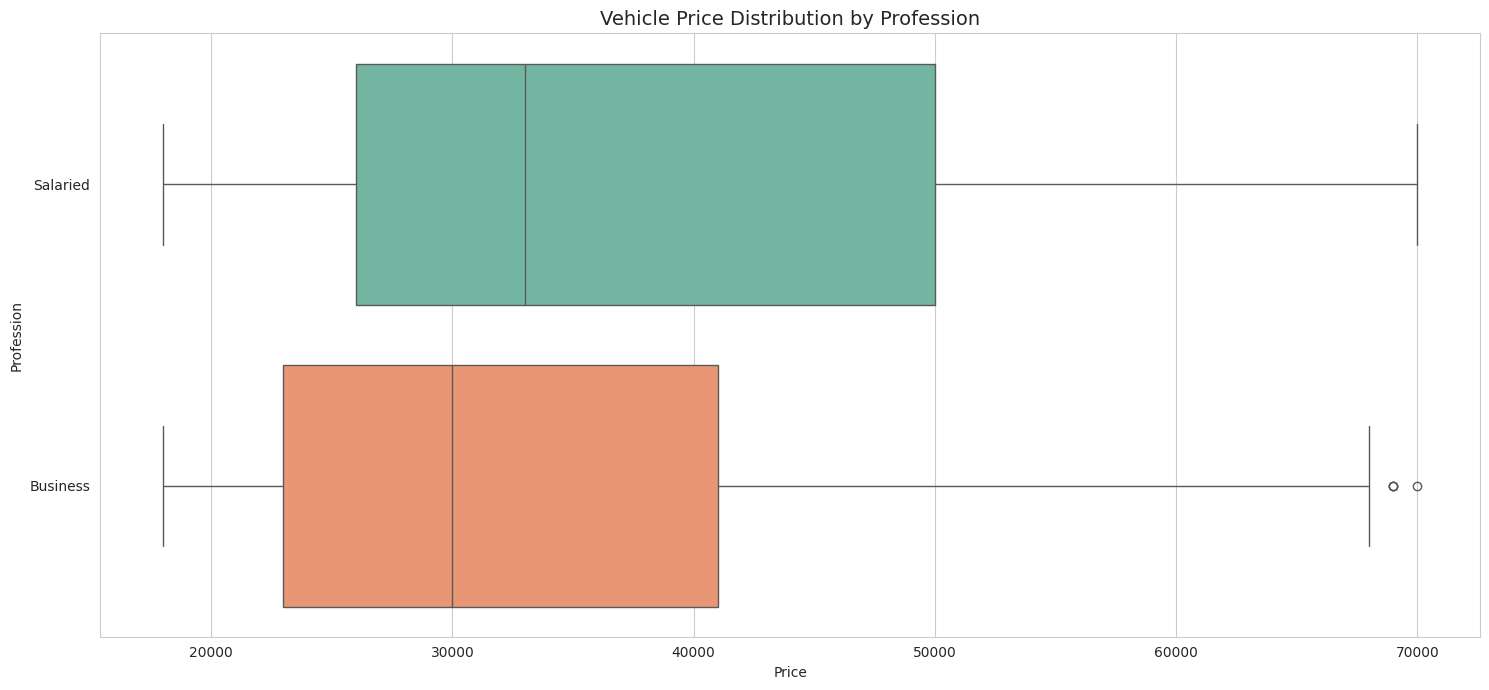

In [ ]:
# Set a clean visual style
sns.set_style("whitegrid")

# Create a boxplot to visualize price distribution by profession
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=data,
    x="Price",
    y="Profession",
    palette="Set2"
)

# Add titles and axis labels
plt.title("Vehicle Price Distribution by Profession", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Profession")

# Adjust layout and display plot
plt.tight_layout()
plt.show()

#### Observation


* **Median Price:** The median price for vehicles purchased by the **Salaried** profession (indicated by the vertical line inside the green box) is noticeably higher than the median price for the **Business** profession (vertical line inside the orange box).
* **Interquartile Range (IQR):** The **Salaried** profession has a smaller Interquartile Range (the length of the box), suggesting that the middle 50% of vehicle prices are less spread out (more consistent) compared to the **Business** profession, which has a wider IQR.
* **Range (Excluding Outliers):** The overall price range (from the end of the left whisker to the end of the right whisker) is wider for the **Salaried** profession, spanning from approximately $\$17,500$ to around $\$70,000$ (with the upper limit of the box at about $\$50,000$).
* **Outliers:** The **Business** profession shows a few clear outliers on the higher end, indicating some purchases at significantly higher prices (around $\$68,000$ to $\$70,000$) compared to the bulk of their transactions. The **Salaried** profession does not display obvious outliers within the visible range.

###### Profession vs Price vs Education

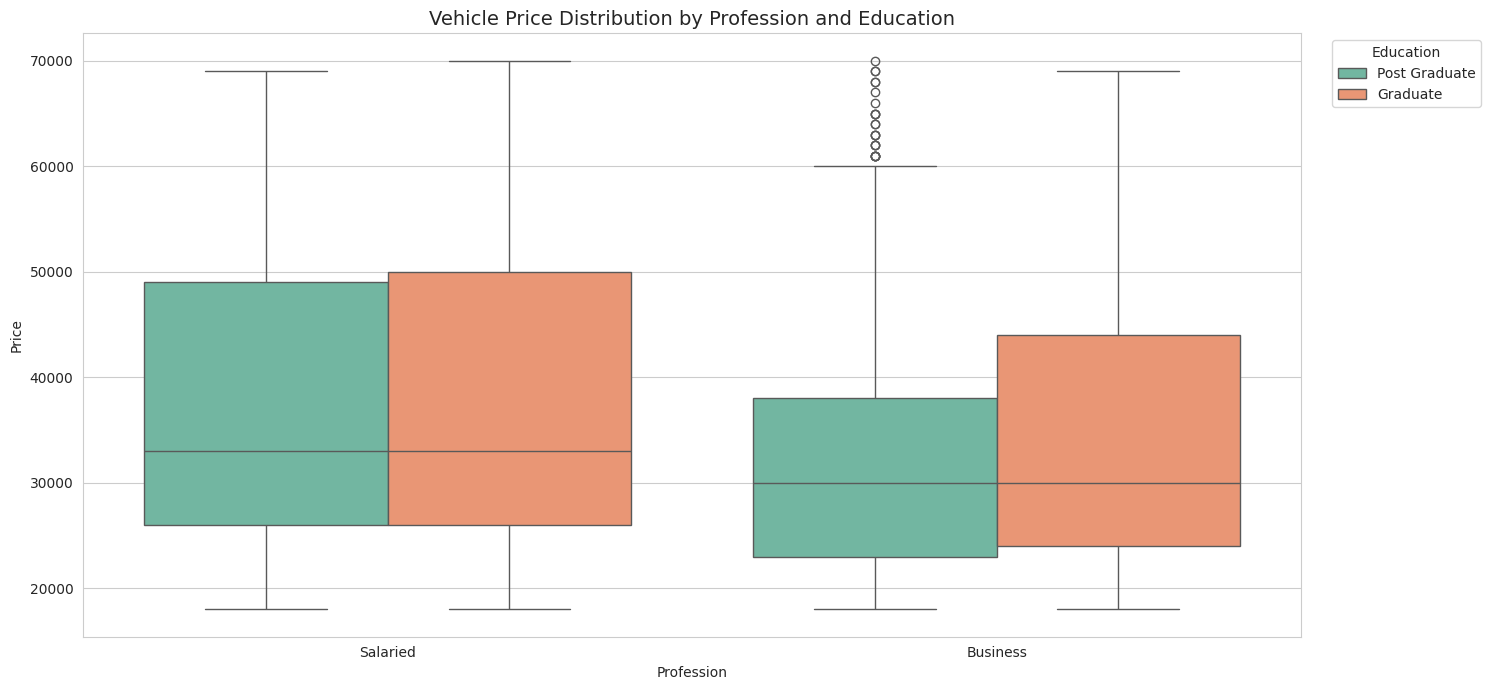

In [ ]:
# Set style
sns.set_style("whitegrid")

# Boxplot with three variables
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=data,
    x="Profession",
    y="Price",
    hue="Education",
    palette="Set2"
)

# Improve legend placement
plt.legend(title="Education", bbox_to_anchor=(1.02, 1), loc="upper left")

# Labels and title
plt.title("Vehicle Price Distribution by Profession and Education", fontsize=14)
plt.xlabel("Profession")
plt.ylabel("Price")

plt.tight_layout()
plt.show()


#### Observations

### **Salaried Profession**

* **Medians are Similar:** The median vehicle price for **Salaried** individuals is almost identical for both **Post Graduates** and **Graduates** (around $\$33,000$).
* **Graduates have a Wider IQR:** **Salaried Graduates** (orange box) have a wider Interquartile Range (IQR) than **Salaried Post Graduates** (green box), suggesting their middle 50% of purchases are more dispersed.
* **Similar Price Ranges:** Both education levels within the Salaried profession share a similar overall price range, spanning from approximately $\$17,500$ to $\$70,000$.

### **Business Profession**

* **Median Difference:** **Business Graduates** have a higher median vehicle price (around $\$30,000$) compared to **Business Post Graduates** (around $\$25,000$).
* **Graduates have a Wider IQR:** Similar to the Salaried group, **Business Graduates** (orange box) show a wider IQR than **Business Post Graduates** (green box), indicating a greater spread in the middle 50% of prices.
* **Extreme Outliers for Post Graduates:** The **Business Post Graduate** group has numerous high-end outliers, with prices clustered around $\$60,000$ to $\$70,000$, suggesting a few high-value purchases that are significantly above the typical price range for this group.
* **Lower $Q_3$ for Post Graduates:** The 75th percentile ($Q_3$) for **Business Post Graduates** is notably lower (around $\$38,000$) than the 75th percentile for **Business Graduates** (around $\$44,000$).

#### Question 10:For customers who have 3 or fewer dependents, how does the average car price vary by profession ? [2 marks]

In [ ]:
# Filter records where the number of dependents is less than or equal to 3
df_dependents = data[data["No_of_Dependents"] <= 3]

# Calculate the average vehicle price by profession
df_profession_avg_price = (
    df_dependents
    .groupby("Profession", as_index=False)["Price"]
    .mean()
    .sort_values(by="Price", ascending=False)
)

# Display the result
df_profession_avg_price


,Profession,Price
1,Salaried,37036.175711
0,Business,32830.220713


#### Observations:

  * **Salaried Professionals Pay More:** Customers who are **Salaried** professionals purchase cars with a higher average price ($\approx \$37,036.20$) compared to those in Business.
  * **Business Professionals Pay Less:** Customers in a **Business** profession purchase cars with a lower average price ($\approx \$32,830.20$) for this dependent group.
  * **Price Difference:** The difference in average car price between Salaried and Business professionals in this group is substantial, approximately \*\*$\$4,206** ($$37,036.20 - $32,830.20$).


#### Question 11: For customers who have availed a home loan and a personal loan, how does the price vary by profession? [3 marks]

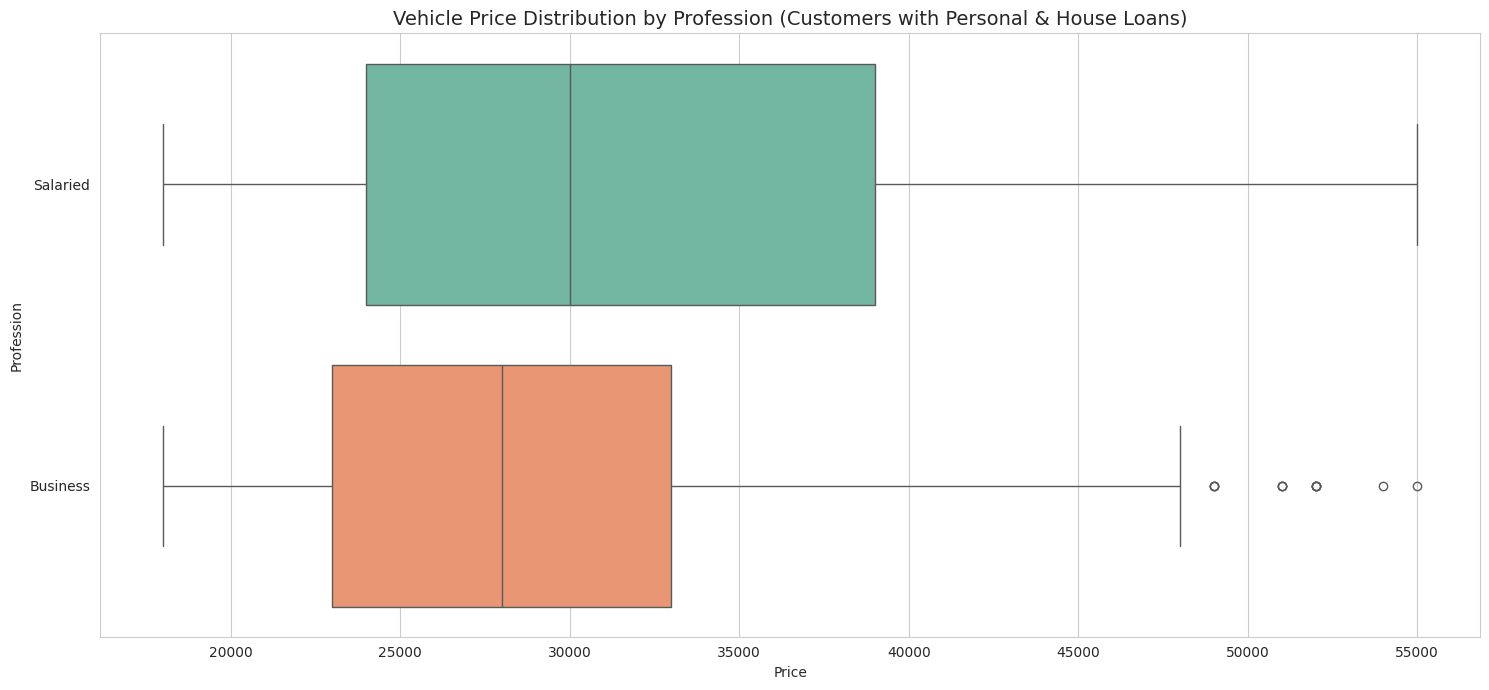

In [ ]:

# Filter customers who have both personal and house loans
loan_holders_df = data[
    (data["Personal_loan"] == "Yes") &
    (data["House_loan"] == "Yes")
]

# Set plot style
sns.set_style("whitegrid")

# Create boxplot to analyze price distribution by profession
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=loan_holders_df,
    x="Price",
    y="Profession",
    palette="Set2"
)

# Add titles and labels
plt.title("Vehicle Price Distribution by Profession (Customers with Personal & House Loans)", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Profession")

# Display plot
plt.tight_layout()
plt.show()


#### Observations:

  * **Salaried Professionals Pay More:** Salaried customers, on average, purchase a more expensive car ($\approx \$32,463.10$) compared to Business customers.
  * **Business Professionals Pay Less:** Business customers purchase the least expensive car on average ($\approx \$30,472.90$) within this highly indebted group.
  * **Price Difference:** The price difference between the two professional groups is modest, with Salaried customers paying approximately \$1,990
  more than Business customers.


## Conclusion and Recommendations

#### **Question 12:** Write the conclusions and business recommendations derived from the analysis. (6 marks)

### Conclusions: Buyer's Profiles and Demand Trends

The US market study identifies three major customer segments based on car type, with demand heavily concentrated on mid-sized family structures.

#### **1. General Market Trends**

* **Dominant Family Size:** The core target market consists of mid-sized families. Over two-thirds of the customers have either **2 or 3 dependents** (35.2% each), making them the most significant demographic for Austo to target.
* **Financial Risk/Opportunity:** A small but notable segment of owners (approximately 6.07%) purchased a car priced higher than their personal salary. Of this group, a significant portion (approximately 45.83%) relies on a personal loan to make the purchase. This indicates a willingness to finance higher-priced vehicles.
* **House Loan Status:** The **Hatchback** is the most preferred car make, regardless of whether the customer has a house loan or not. Customers without a house loan represent a higher-volume market for all car types.

#### **2. Buyer's Profiles by Car Type**

| Car Type | Primary Target Group | Demand Trend / Key Insight |
| :--- | :--- | :--- |
| **Hatchback** | **Mass Market / Practical Family** | Highest overall demand across all segments, and favored by customers both with and without a house loan. Popular for small-to-mid-sized families (1, 2, or 3 dependents). |
| **SUV** | **Mid-Sized Family / Utility-Oriented** | Preference for SUVs generally **increases** with family size (from 0 up to 3 dependents). This segment prioritizes space and utility for a growing family. |
| **Sedan** | **Individuals / Small Families** | Demand peaks at **1 and 2 dependents**, dropping significantly for 3 dependents, and is virtually non-existent for 4 dependents. Sedans appeal to smaller households where space is not the primary constraint. |

---

### Business Recommendations for Austo

The following recommendations are designed to help Austo strategically enter and expand within the US automobile market:

1.  **Prioritize the Hatchback Segment for Launch:**
    * Austo should focus its initial production and marketing efforts on launching a competitive line of **Hatchbacks**. This car type exhibits the highest, most consistent demand across diverse customer segments.
    * The models should be marketed as practical, affordable, and fuel-efficient for the general population and young families.

2.  **Strategic SUV Development to Target Mid-Sized Families:**
    * A secondary, high-priority launch should focus on **SUVs**, as they cater directly to the large segment of customers with 2 or 3 dependents.
    * Marketing and features should emphasize safety, cargo space, and seating comfort to appeal to the utility needs of mid-sized families.

3.  **Develop an In-House Financing Program:**
    * To capture the significant segment of buyers who purchase a car priced above their salary (approximately 6.07% of the market), Austo should establish in-house lending and financing options.
    * Offering competitive financing could convert high-risk buyers who currently rely on external personal loans (45.83% of the overextended group) into loyal Austo customers.

4.  **Targeted Marketing for Sedans:**
    * Position Sedans as cars for individuals, couples, or small families (1–2 dependents). Focus marketing on design, performance, and features, rather than family utility.

5.  **Avoid Niche Markets in the Initial Phase:**
    * The demand for vehicles for very large families (4 or more dependents) is comparatively lower. Austo should postpone the development or launch of large vans/minivans and focus resources on the proven, higher-volume Hatchback and SUV segments.


___